# Cell-cell communication analysis with LIANA+

## Overview

This tutorial is built around the LIANA+ `rank_aggregate` workflow and routes the results into the OmicVerse `ccc_*` visualization stack.

1. `ov.pl.ccc_heatmap`
2. `ov.pl.ccc_network_plot`
3. `ov.pl.ccc_stat_plot`

The point of this structure is to establish, up front, which kinds of biological questions each view answers, and then move into concrete plotting examples.

This notebook keeps two complementary workflows:

- Main workflow: pass the original `adata` directly into `ccc_*`
- Optional workflow: explicitly extract `comm_adata` for inspection and comparison examples

## Method background

According to the [LIANA documentation](https://liana-py.readthedocs.io/en/stable/) and the [LIANA+ paper](https://www.nature.com/articles/s41556-024-01469-w), LIANA+ is a framework for cell-cell communication analysis that harmonizes ligand-receptor resources and multiple scoring strategies. In this notebook we focus on `rank_aggregate`, which is a strong default because it:

- defines sender and receiver groups from cell labels
- scores ligand-receptor interactions from normalized expression patterns
- aggregates evidence across methods into a consensus ranking
- returns a standardized result table that is easy to route into OmicVerse plotting functions

This consensus-style setup is helpful when prioritizing candidate communication axes before pathway-level or network-level interpretation.

## Why use `pbmc68k_reduced` here?

`pbmc68k_reduced` is lightweight, already contains UMAP coordinates, and provides a moderate number of immune cell groups. That makes it suitable for demonstrating the LIANA+ inference workflow and the downstream communication plots in one notebook.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import omicverse as ov

ov.plot_set(font_path='Arial')

%reload_ext autoreload
%autoreload 2

🔬 Starting plot initialization...
Using already downloaded Arial font from: /var/folders/rv/3jnfbs0d6r7d0c5bfj7ft5k00000gn/T/omicverse_arial.ttf


Matplotlib is building the font cache; this may take a moment.


Registered as: Arial
🧬 Detecting GPU devices…
✅ Apple Silicon MPS detected
    • [MPS] Apple Silicon GPU - Metal Performance Shaders available

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load the example dataset

LIANA's official tutorials also use an `AnnData` workflow. Here we use `pbmc68k_reduced` and `adata.obs['bulk_labels']` as the communication grouping.

This dataset is a good tutorial choice because:

- it is lightweight enough to demonstrate many `ccc_*` views end to end
- it already contains UMAP coordinates for layout checks and embedding-based network plots
- the number of cell types is large enough to expose real facet and matrix structure without making every plot collapse

In [2]:
adata = sc.datasets.pbmc68k_reduced()
adata


AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

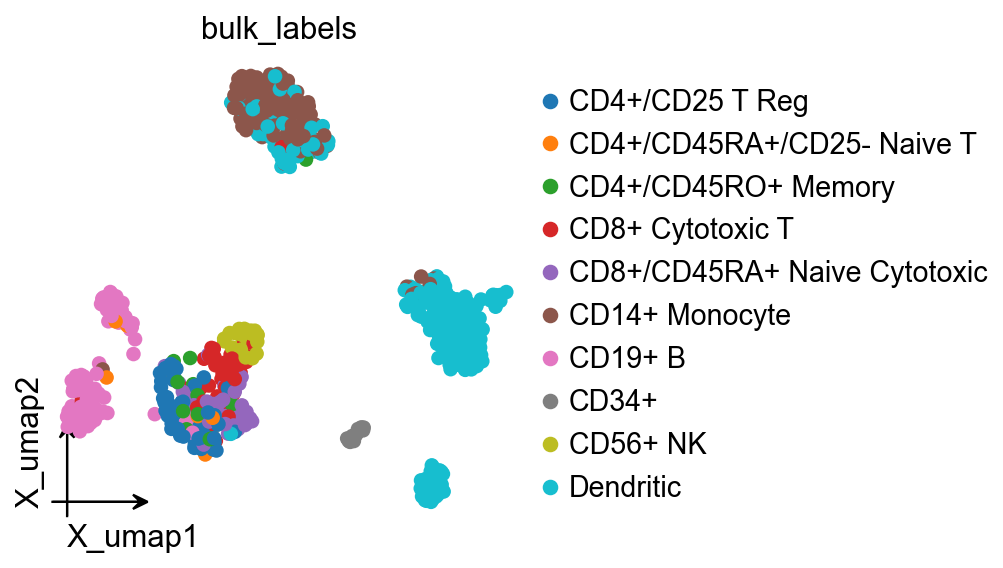

In [3]:
ov.pl.embedding(
    adata,
    basis='X_umap',
    color='bulk_labels',
    frameon='small'
)


## 2. Run LIANA+ rank aggregation

We use `ov.single.run_liana(...)` as a wrapper around `liana.mt.rank_aggregate` and store the result in `adata.uns['liana_res']`.

Why `method='rank_aggregate'` is the default here:

- the aggregated consensus score is the most natural input for the unified OmicVerse `ccc_*` visualizations
- it compresses evidence from multiple CCC methods into a single ranking, which is a clear default tutorial entry point
- it keeps the result table consistent for downstream pathway-level aggregation and comparison plots

In [4]:
ov.single.run_liana(
    adata,
    groupby='bulk_labels',
    method='rank_aggregate',
    resource_name='consensus',
    key_added='liana_res',
    inplace=True,
)

adata.uns['liana_res'].head()

         source                      target ligand_complex receptor_complex  \
1209  Dendritic         CD4+/CD45RO+ Memory        HLA-DRA              CD4   
1188  Dendritic  CD4+/CD45RA+/CD25- Naive T        HLA-DRA              CD4   
1210  Dendritic         CD4+/CD45RO+ Memory       HLA-DRB1              CD4   
1205  Dendritic         CD4+/CD45RO+ Memory       HLA-DPB1              CD4   
1189  Dendritic  CD4+/CD45RA+/CD25- Naive T       HLA-DRB1              CD4   

      lr_means  cellphone_pvals  expr_prod  scaled_weight  lr_logfc  \
1209  2.575263              0.0   2.780884       0.723815  1.431302   
1188  2.566905              0.0   2.705027       0.709428  1.332656   
1210  2.415010              0.0   2.584465       0.712731  1.331341   
1205  2.367473              0.0   2.526199       0.731297  1.447014   
1189  2.406652              0.0   2.513965       0.698344  1.232695   

      spec_weight   lrscore  specificity_rank  magnitude_rank  
1209     0.065077  0.736772       

## 3. Optional: extract the standardized communication AnnData

Most `ccc_*` calls no longer require users to manually build `comm_adata`, because the plotting functions can auto-detect `adata.uns['liana_res']`.

We still extract it explicitly once for three reasons:

1. to inspect how LIANA columns are mapped into standardized communication score / p-value layers
2. to confirm that pathway / classification annotations are available
3. to simplify the later synthetic comparison and differential-network examples


In [5]:
comm_adata = ov.single.to_comm_adata(
    adata,
    result_uns_key='liana_res',
    score_key='specificity_rank',
    pvalue_key='specificity_rank',
    classification_reference='cellchat',
    classification_fallback='family',
)

comm_adata

AnnData object with n_obs × n_vars = 100 × 42
    obs: 'sender', 'receiver', 'cell_type_pair'
    var: 'interacting_pair', 'pair_lr', 'interaction_name', 'interaction_name_2', 'classification', 'pathway_name', 'signaling', 'gene_a', 'gene_b', 'ligand', 'receptor', 'annotation_strategy', 'classification_source'
    uns: 'liana_score_key', 'liana_pvalue_key', 'liana_uns_key', 'liana_sample_key', 'liana_classification_reference', 'liana_classification_fallback', 'liana_classification_source_counts'
    layers: 'means', 'pvalues', 'lr_means', 'cellphone_pvals', 'expr_prod', 'scaled_weight', 'lr_logfc', 'spec_weight', 'lrscore', 'specificity_rank', 'magnitude_rank'

In [6]:
comm_adata.var[['classification', 'classification_source']].value_counts().head()

classification  classification_source   
MHC-II          reference:cellchat_human    10
                family                       8
ECM/Adhesion    family                       6
Unclassified    unclassified                 5
TNF             family                       3
Name: count, dtype: int64

In [7]:
focus_pathways = [
    value
    for value in comm_adata.var['classification'].dropna().astype(str).unique().tolist()
    if value not in {'Unclassified', 'nan'}
]
focus_pathway = focus_pathways[0] if focus_pathways else 'Unclassified'
focus_pair_lr = comm_adata.var['interacting_pair'].astype(str).iloc[10]
ligand_series = comm_adata.var['ligand'].astype(str)
focus_ligand = ligand_series[ligand_series != ''].iloc[0]

color_dict = dict(
    zip(
        sorted(adata.obs['bulk_labels'].astype(str).unique()),
        ov.pl.sc_color[: adata.obs['bulk_labels'].nunique()],
    )
)

umap_df = pd.DataFrame(
    adata.obsm['X_umap'][:, :2],
    columns=['x', 'y'],
    index=adata.obs_names,
)
umap_df['cell_type'] = adata.obs['bulk_labels'].astype(str).values
node_positions = umap_df.groupby('cell_type', observed=True)[['x', 'y']].median()
embedding_points = umap_df.reset_index(drop=True)
comm_adata.uns['node_positions'] = node_positions
comm_adata.uns['embedding_points'] = embedding_points
comm_adata.uns['embedding_axes'] = ('UMAP_1', 'UMAP_2')

comparison_comm = comm_adata.copy()
comparison_comm.layers['means'] = np.asarray(comm_adata.layers['means']).copy() * 0.85
comparison_comm.layers['pvalues'] = np.clip(
    np.asarray(comm_adata.layers['pvalues']).copy() * 1.1,
    0.0,
    1.0,
)

focus_pathway, focus_pair_lr, focus_ligand

('ANNEXIN', 'HLA-DPA1_CD4', 'ANXA1')

# 1. `ov.pl.ccc_heatmap`

This group of plots mainly answers three questions:

- which sender / receiver / interaction combinations dominate
- which signaling families become most active after pathway-level aggregation
- which dense matrix views are better suited for compressed summaries

For LIANA, the first views worth mastering are:

- `plot_type='dot'`: the clearest source-target-interaction decomposition
- `plot_type='tile'`: split ligand-side and receptor-side summaries
- `plot_type='heatmap'`: pathway/family-level aggregation


## 1.1 The main LIANA dot view

This should be the default entry point for interaction-level inspection.

- Facets: source
- x-axis: target
- y-axis: interaction
- color: communication score

It is the clearest way to inspect sender, target, and interaction simultaneously.


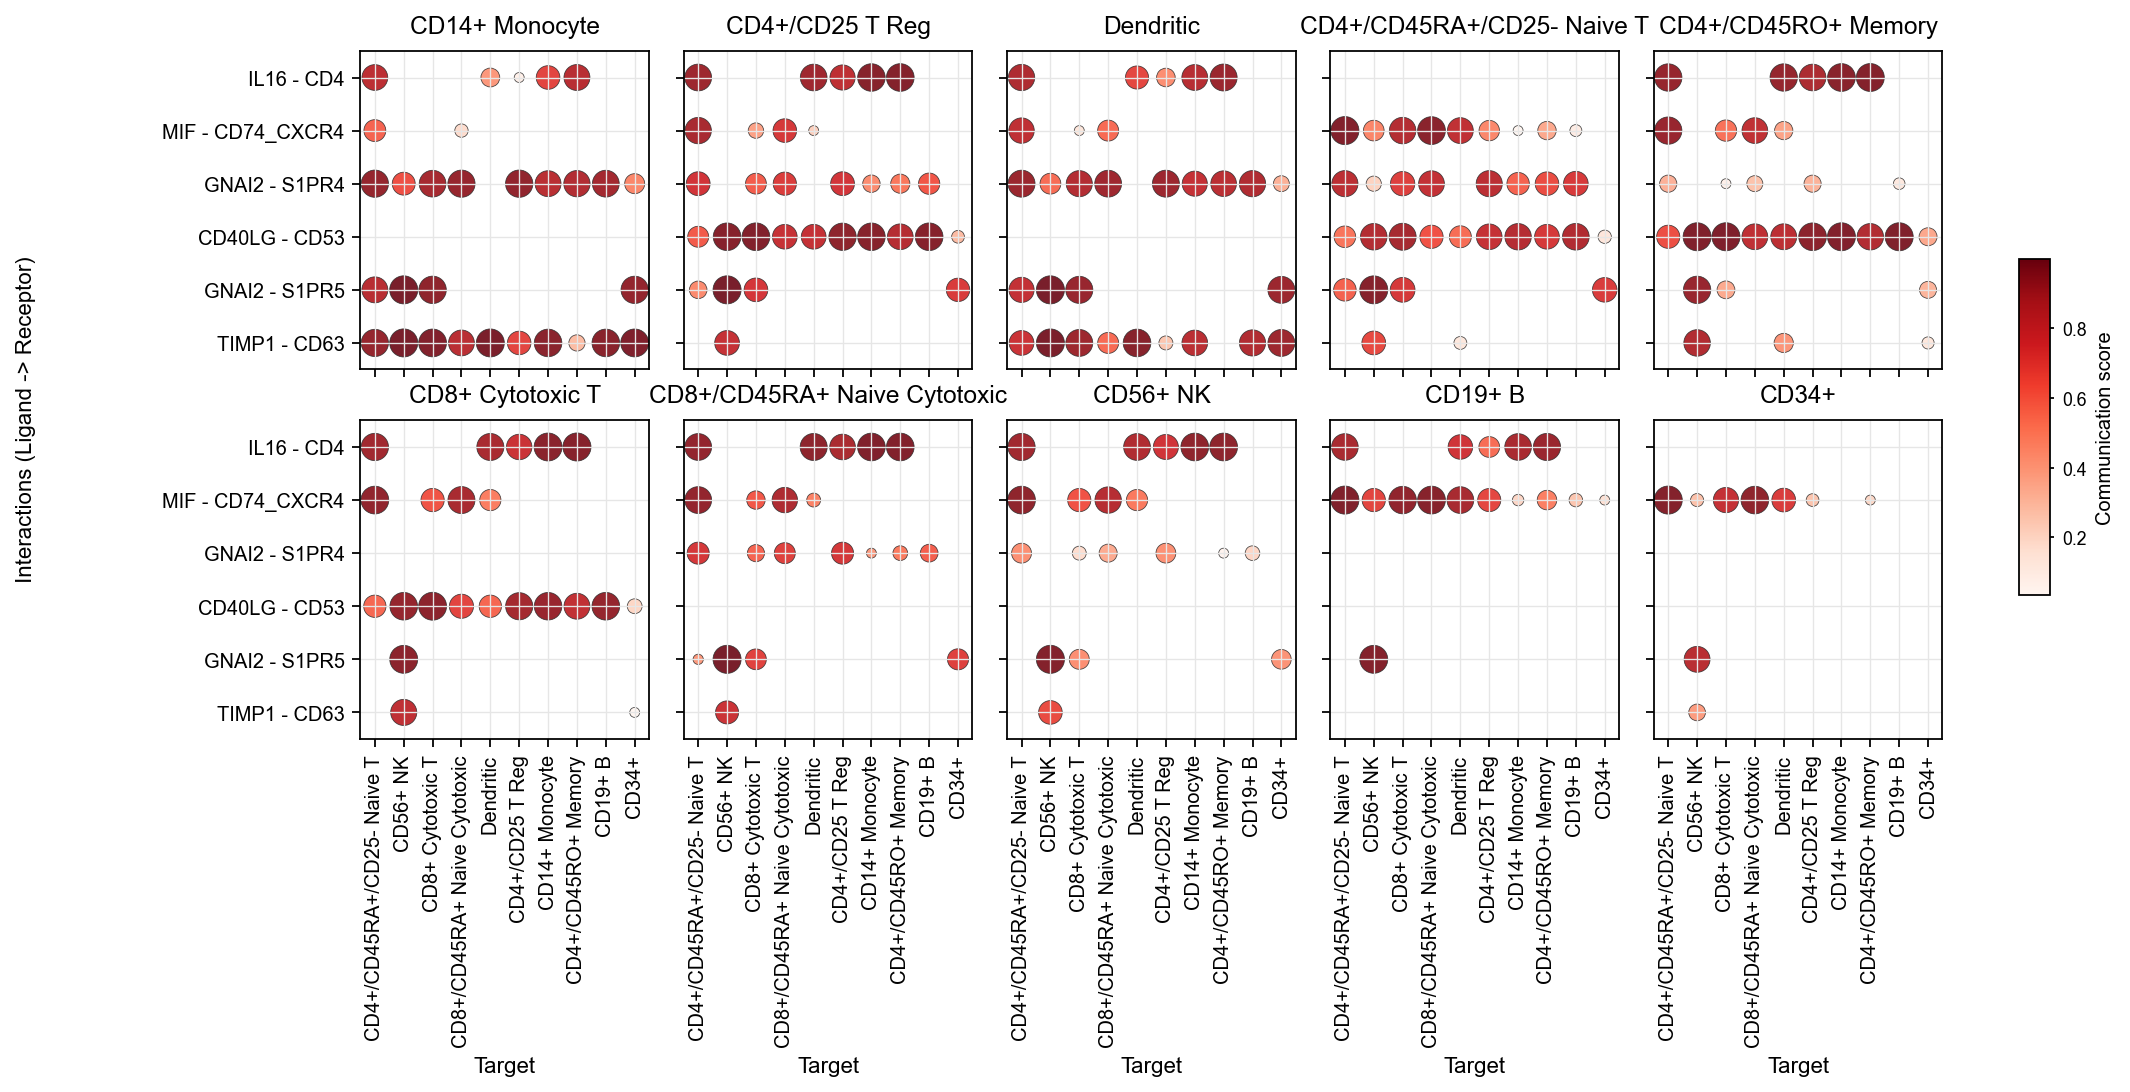

In [8]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    plot_type='dot',
    display_by='interaction',
    score_key='specificity_rank',
    pvalue_key='specificity_rank',
    classification_reference='cellchat',
    classification_fallback='family',
    top_n=6,
    pvalue_threshold=0.05,
    color_by='score',
    ncols=5,
    figsize=(16, 5),
    show=False,
)

## 1.2 Sender-focused dot plots

Once you already know which sender you care about, use `sender_use` to narrow the view.

This is useful for questions such as:

- which targets a given sender primarily communicates with
- which interactions dominate that sender

Here, we use the extracted `comm_adata` using `ov. single. to_commaddrata` for plotting, taking `CD34+` as an example:

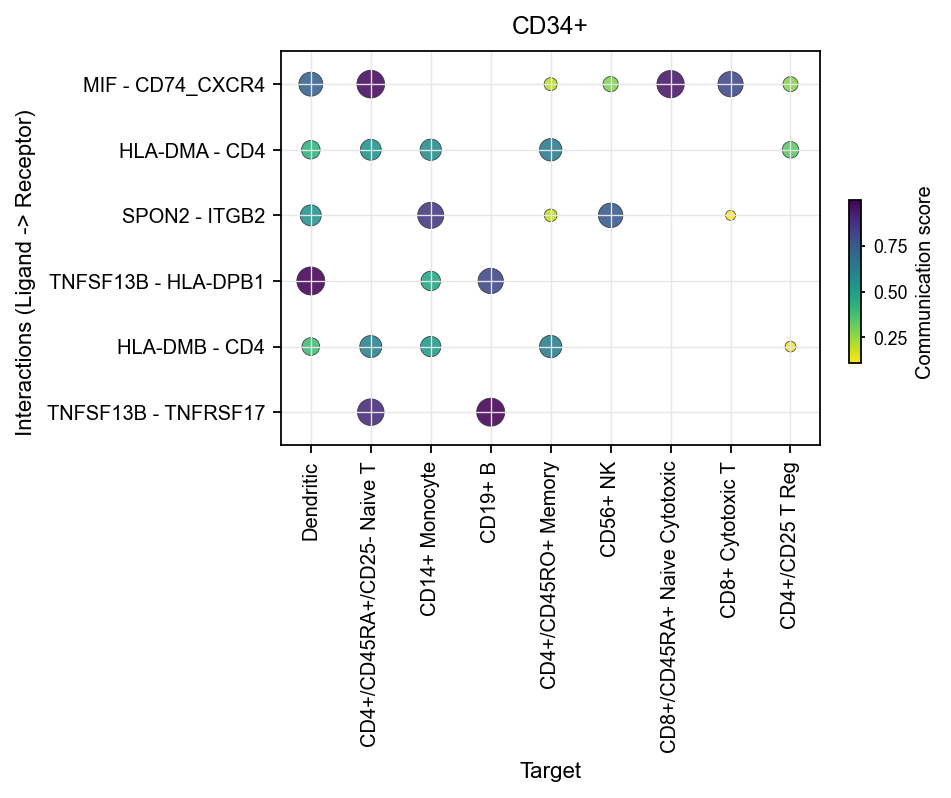

In [9]:
fig, ax = ov.pl.ccc_heatmap(
    comm_adata,
    plot_type='dot',
    display_by='interaction',
    score_key='specificity_rank',
    pvalue_key='specificity_rank',
    sender_use='CD34+',
    top_n=6,
    pvalue_threshold=0.05,
    color_by='score',
    cmap='viridis_r',
    figsize=(6, 3),
    show=False,
)

Likewise, you can focus the plot with `receiver_use`.


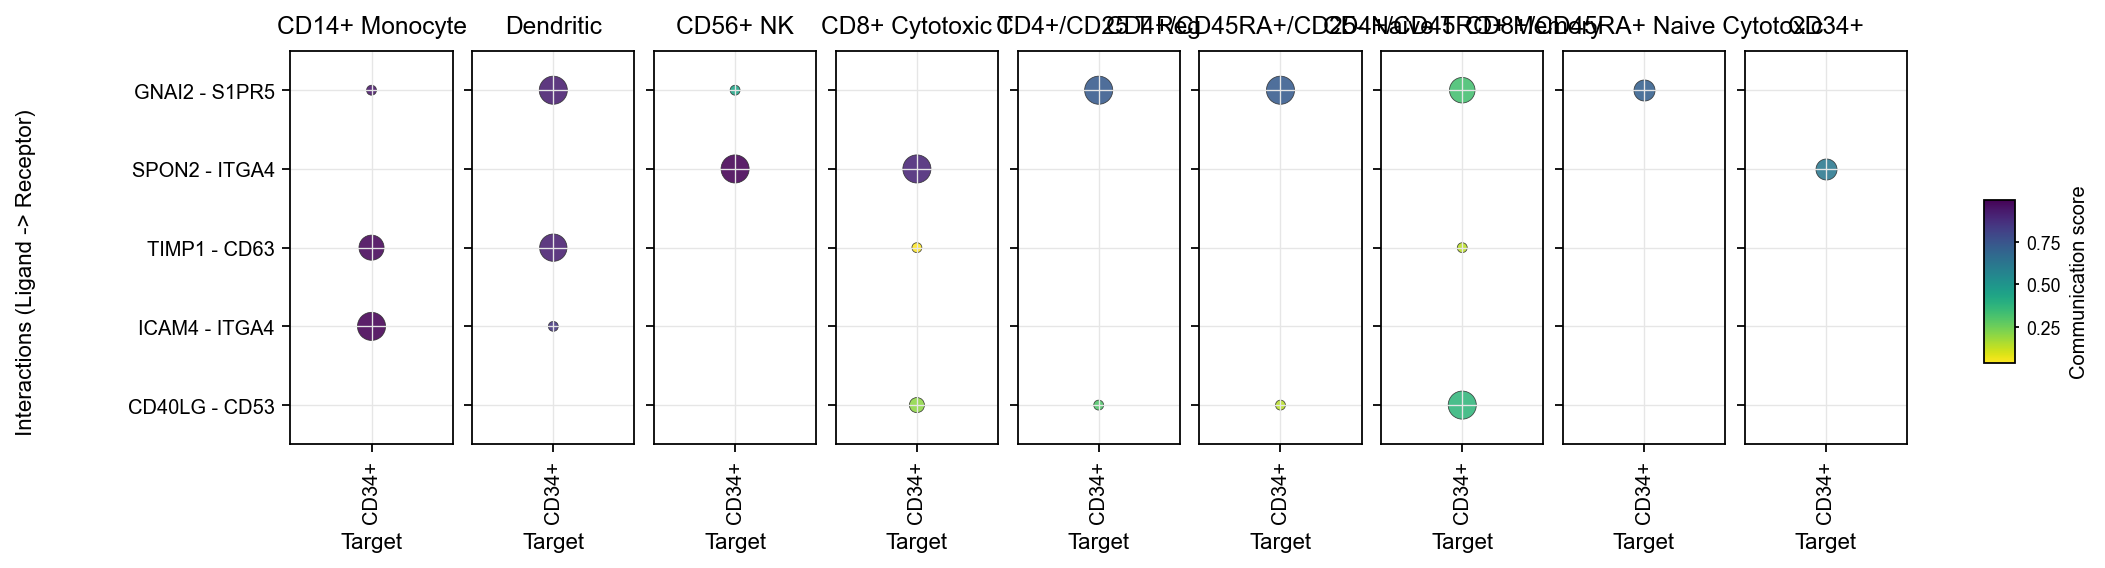

In [10]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    plot_type='dot',
    display_by='interaction',
    score_key='specificity_rank',
    pvalue_key='specificity_rank',
    receiver_use='CD34+',
    top_n=5,
    pvalue_threshold=0.05,
    color_by='score',
    cmap='viridis_r',
    figsize=(16, 3),
    show=False,
)

## 1.3 Tile plots

`tile` is useful when you want to look at the same interaction set from the ligand and receptor sides separately.

- Left heatmap: `Source ligand`
- Right heatmap: `Target receptor`


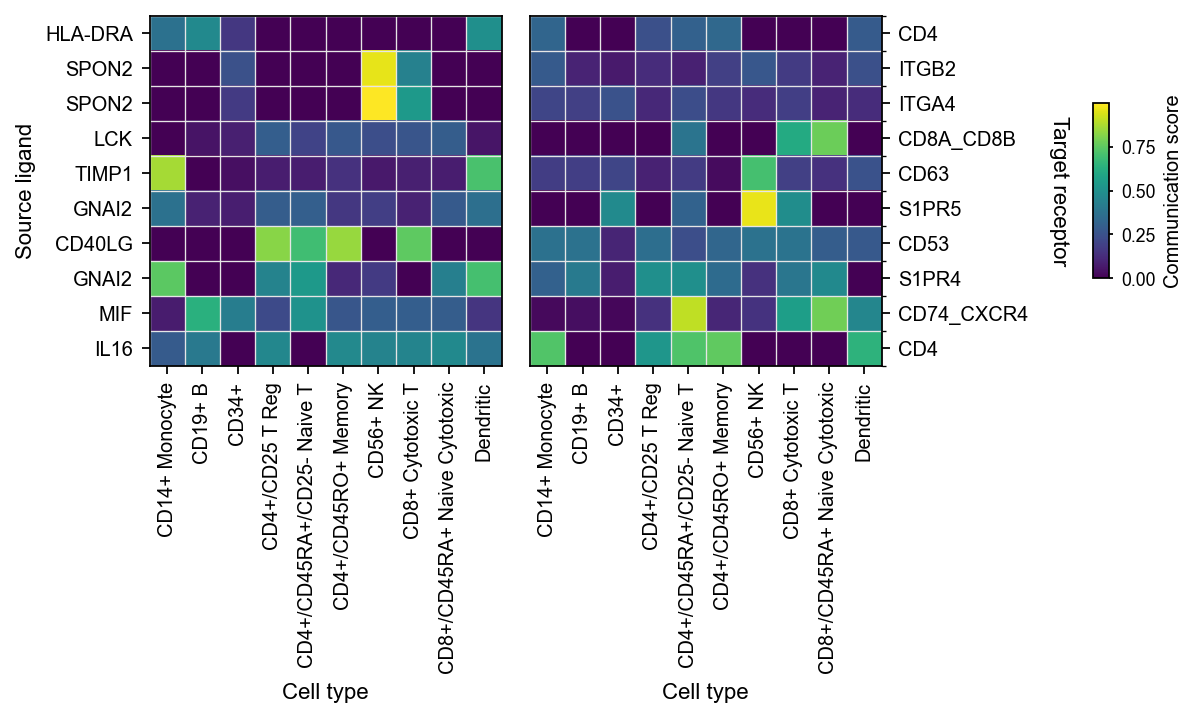

In [11]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    plot_type='tile',
    display_by='interaction',
    score_key='specificity_rank',
    pvalue_key='specificity_rank',
    top_n=10,
    pvalue_threshold=0.05,
    cmap='viridis',
    figsize=(8, 3),
    show=False,
)

## 1.4 Pathway aggregation heatmap

When the question shifts from “which interaction is strongest” to “which signaling family is most active”, the correct view is an aggregation-level heatmap.

This is where `classification_reference='cellchat'` and `classification_fallback='family'` really matter, because they determine how ligand-receptor pairs are assigned into pathway/family groups.


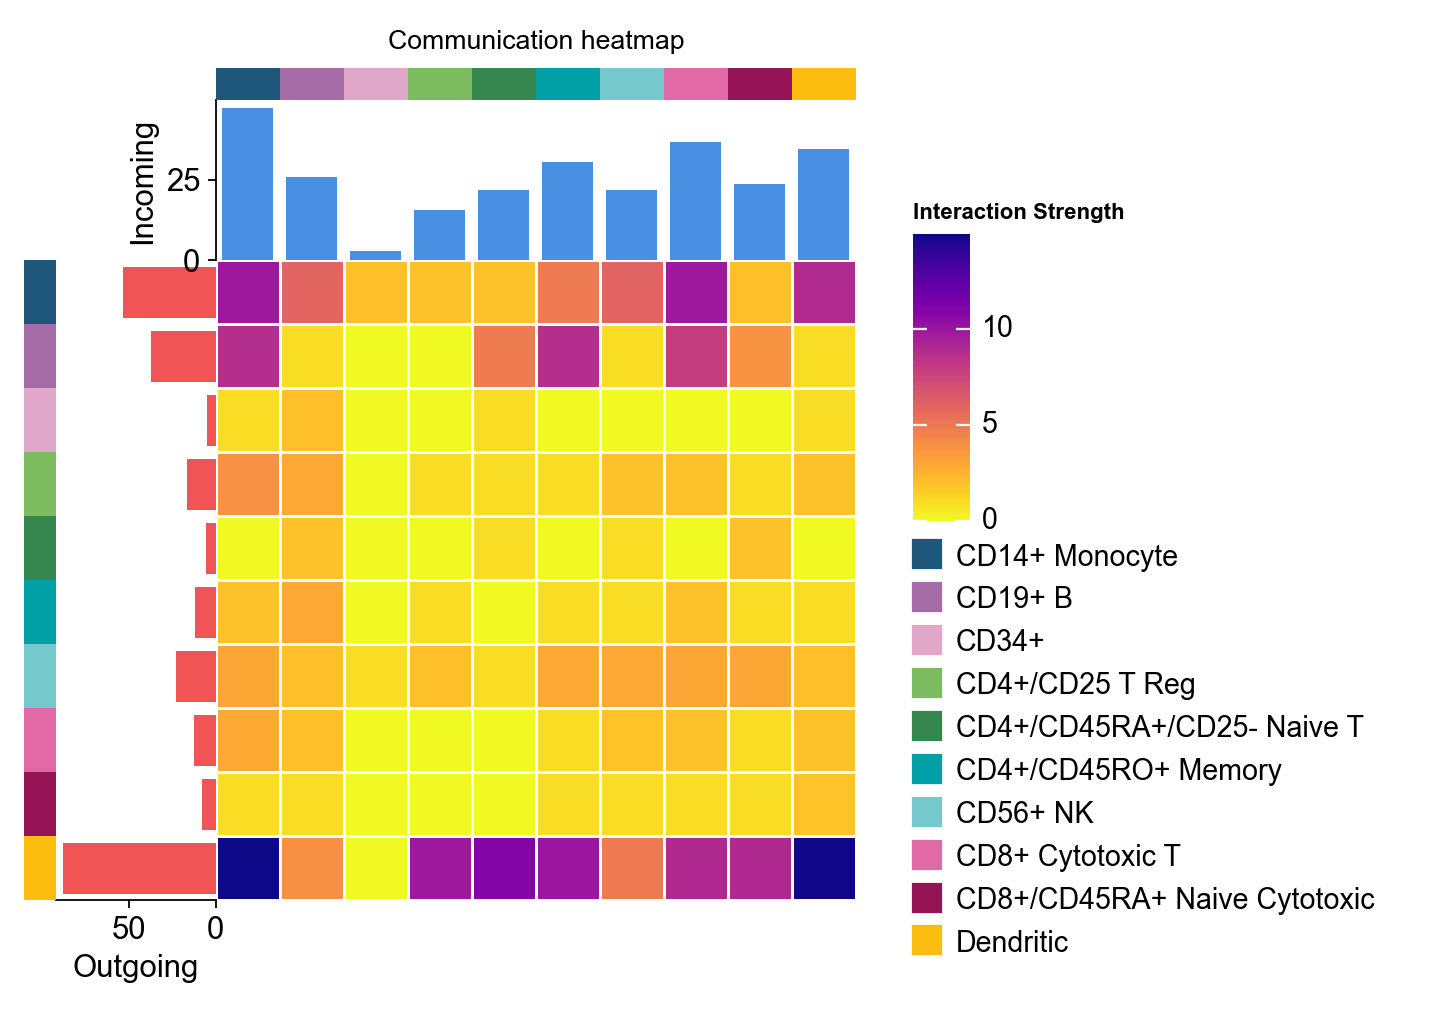

In [12]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    plot_type='heatmap',
    display_by='aggregation',
    score_key='specificity_rank',
    pvalue_key='specificity_rank',
    classification_reference='cellchat',
    classification_fallback='family',
    top_n=12,
    cmap='plasma_r',
    show=False,
)

## 1.5 Focused heatmap

`focused_heatmap` is used to pull out one pathway and inspect its sender/receiver structure in isolation.


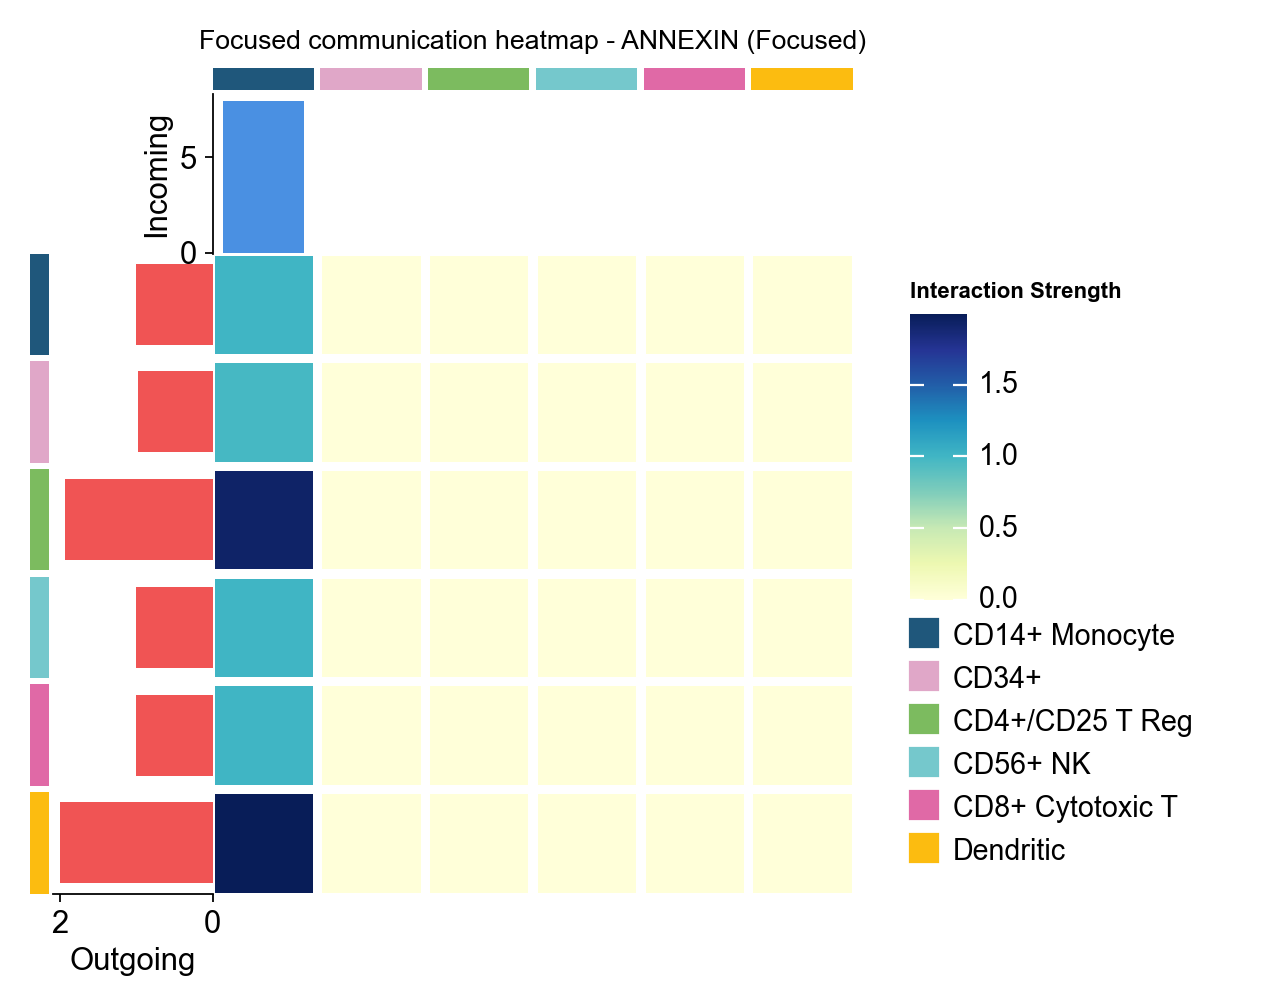

In [13]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    plot_type='focused_heatmap',
    signaling=[focus_pathway],
    min_interaction_threshold=0.0,
    cmap='YlGnBu',
    figsize=(4, 3),
    show=False,
)

## 1.6 Pathway bubble, role heatmap, and role network

These are pathway-level summary views:

- `pathway_bubble`: compact matrix of pathway vs cell-pair activity
- `role_heatmap`: incoming / outgoing summary by cell type
- `role_network`: pathway role relationships organized as a network


📊 Visualization statistics:
   - Number of significant interactions: 5
   - Number of cell type pairs: 5
   - Signaling pathways: 1
   - Data scaling: None (raw expression values)
   - Color bars: sender


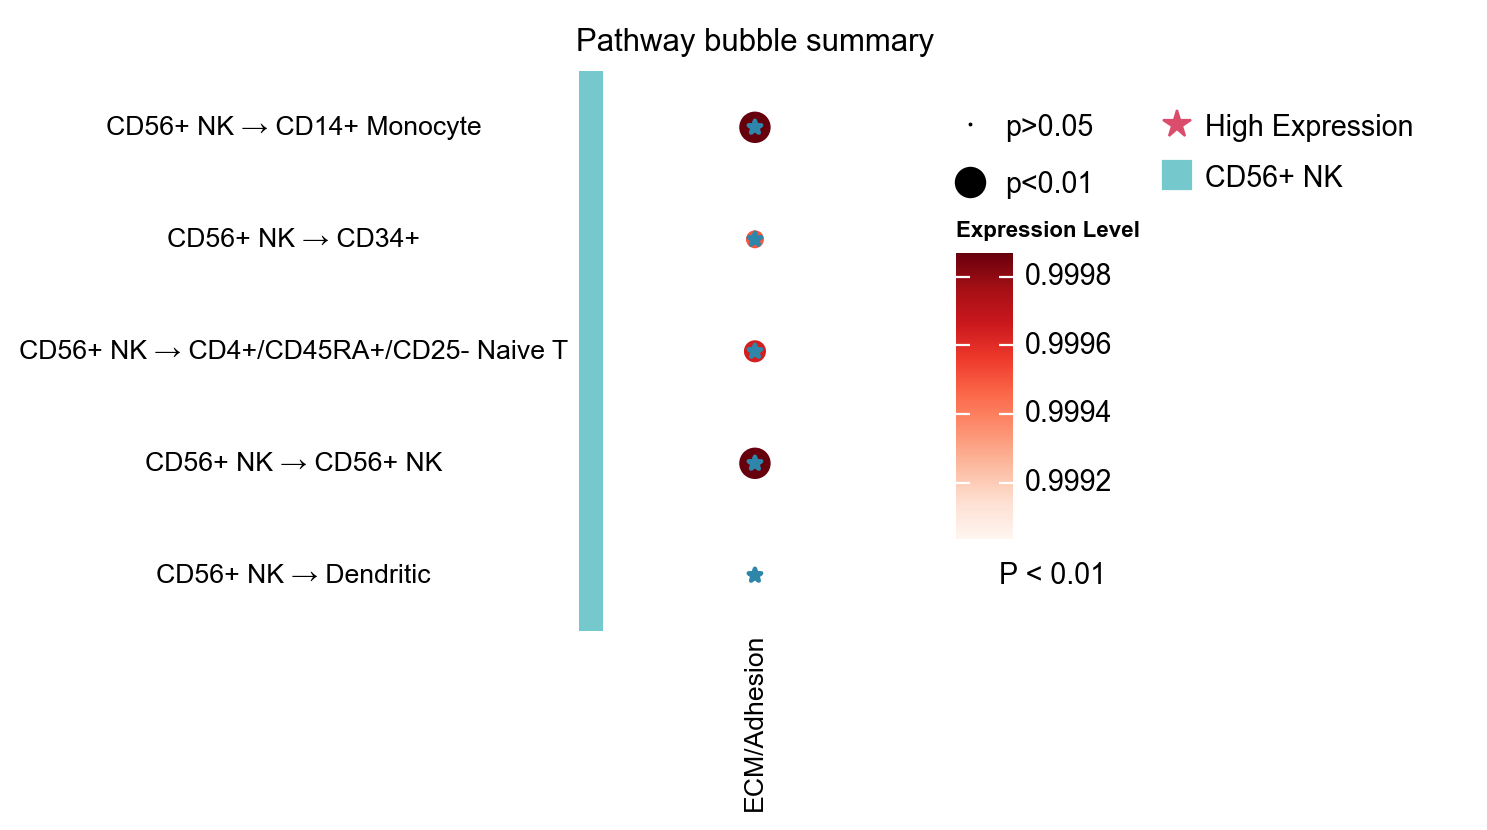

In [14]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    plot_type='pathway_bubble',
    signaling=['ECM/Adhesion'],
    top_n=5,
    figsize=(3, 5),
    show=False,
)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


🔬 Calculating cell communication strength for 11 pathways...
   - Aggregation method: mean
   - Minimum expression threshold: 0.1
✅ Completed pathway communication strength calculation for 11 pathways
📊 Pathway significance analysis results:
   - Total pathways: 11
   - Significant pathways: 11
   - Strength threshold: 0.5
   - p-value threshold: 0.05

🏆 Top 10 pathways by total strength:
----------------------------------------------------------------------------------------------------
Pathway                        Total    Max     Mean    L-R  Active Sig  Rate   Status
----------------------------------------------------------------------------------------------------
Unclassified                   58.62    0.99    0.72    5    81     33   0.41   ***
ECM/Adhesion                   35.78    1.00    0.76    6    47     25   0.53   ***
IL16                           33.61    0.98    0.86    1    39     10   0.26   ***
MIF                            31.59    0.98    0.64    1    49    

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


📊 Heatmap statistics:
   - Number of pathways: 11
   - Number of cell types: 10
   - Signal strength range: 0.000 - 0.900


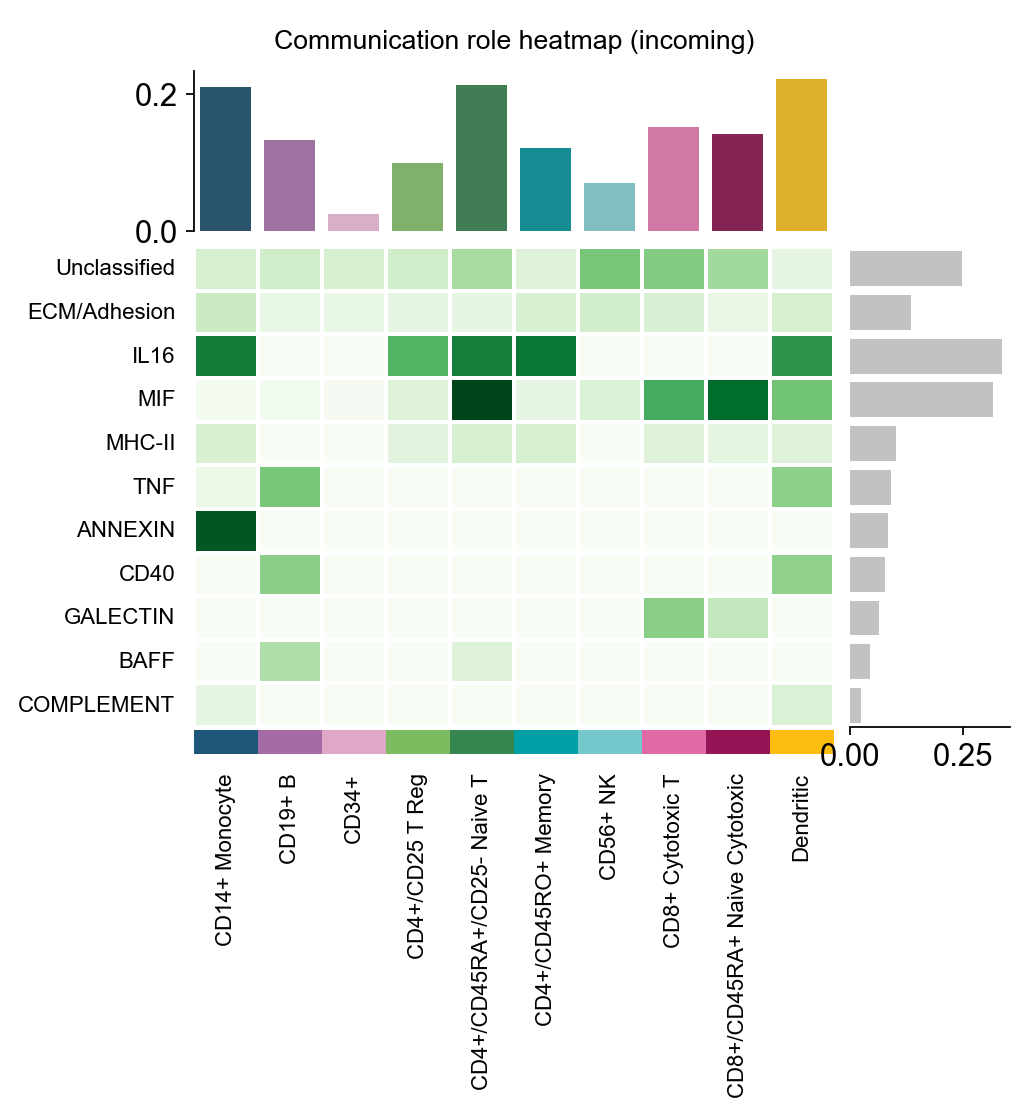

In [15]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    plot_type='role_heatmap',
    pattern='incoming',
    cmap='Greens',
    figsize=(4, 3),
    show=False,
)

✅ Network centrality calculation completed (CellChat-style Importance values)
   - Signaling pathways used: ['ECM/Adhesion']
   - Weight mode: Weighted
   - Calculated metrics: outdegree, indegree, flow_betweenness, information, overall
   - All centrality scores normalized to 0-1 range (Importance values)
📊 Signaling role analysis results (Importance values 0-1):
   - Dominant Sender: CD14+ Monocyte (Importance: 1.000)
   - Dominant Receiver: CD56+ NK (Importance: 1.000)
   - Mediator: CD14+ Monocyte (Importance: 1.000)
   - Influencer: CD14+ Monocyte (Importance: 1.000)


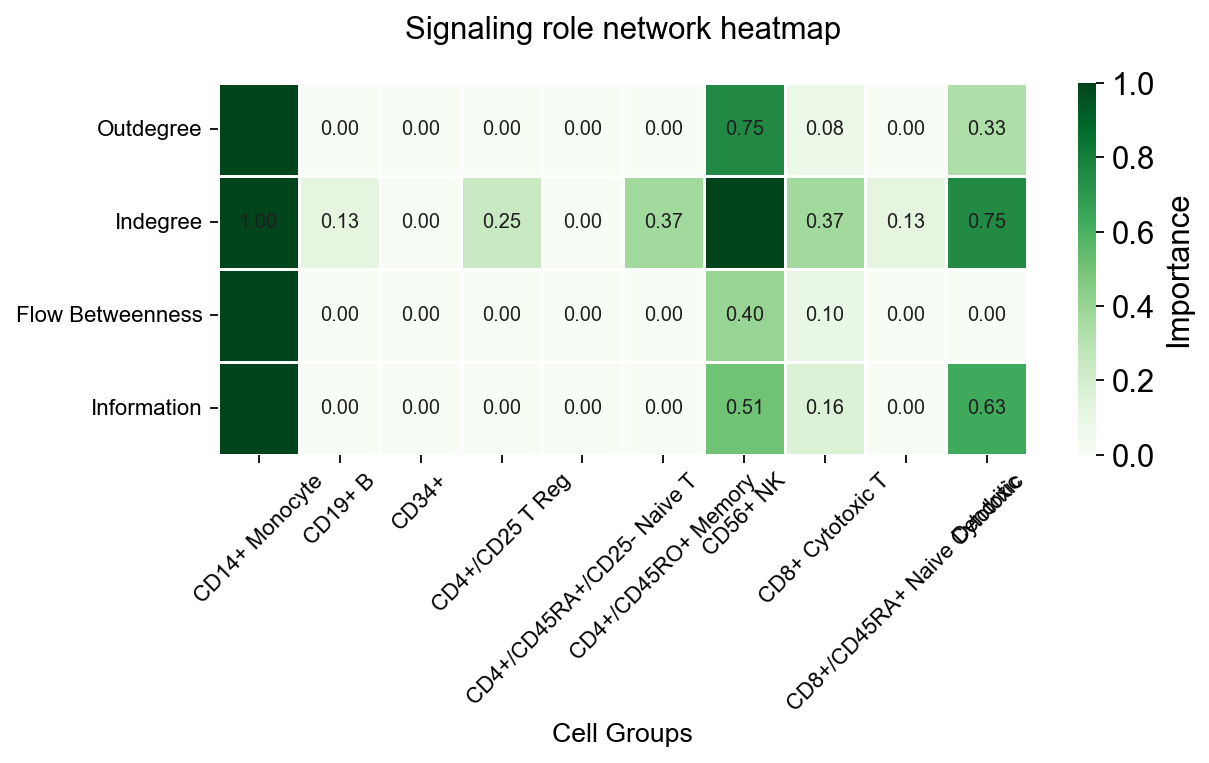

In [16]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    plot_type='role_network',
    signaling=['ECM/Adhesion'],
    cmap='Greens',
    figsize=(8, 5),
    show=False,
)

## 1.7 Sample/context dot plot

`sample_dot` requires a context/sample column in the LIANA result table.

We first demonstrate the API with a synthetic tutorial-style `condition`: duplicate the same `liana_res` twice and manually add `baseline / stimulated`.

This step is only for showing the plotting API. It is not a real condition-comparison analysis.


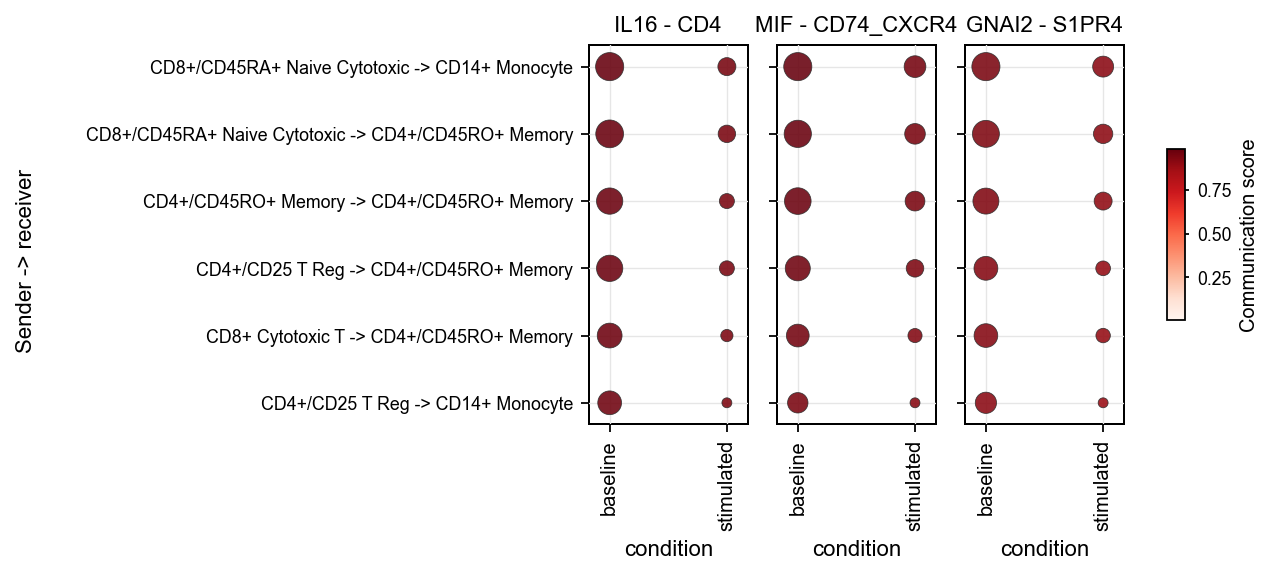

In [17]:
adata_by_context = adata.copy()
frames = []
for condition, delta in [('baseline', 0.0), ('stimulated', 0.03)]:
    frame = adata.uns['liana_res'].copy()
    frame['condition'] = condition
    frame['specificity_rank'] = np.clip(frame['specificity_rank'] + delta, 0.0, 1.0)
    frames.append(frame)
adata_by_context.uns['liana_res'] = pd.concat(frames, ignore_index=True)

fig, ax = ov.pl.ccc_heatmap(
    adata_by_context,
    plot_type='sample_dot',
    display_by='interaction',
    score_key='specificity_rank',
    pvalue_key='specificity_rank',
    sample_key='condition',
    top_n=3,
    top_n_pairs=6,
    pvalue_threshold=0.05,
    figsize=(9, 3),
    show=False,
)

If you have a real `condition` column, the correct workflow is to run LIANA separately per condition and then concatenate the result tables before calling `sample_dot`. A minimal template is shown below.


In [18]:
# condition_key = 'condition'
# result_frames = []
# for condition in sorted(adata.obs[condition_key].dropna().astype(str).unique()):
#     ad_sub = adata[adata.obs[condition_key].astype(str) == condition].copy()
#     ov.single.run_liana(
#         ad_sub,
#         groupby='bulk_labels',
#         method='rank_aggregate',
#         key_added='liana_res',
#         inplace=True,
#     )
#     frame = ad_sub.uns['liana_res'].copy()
#     frame[condition_key] = condition
#     result_frames.append(frame)
# adata_real_context = adata.copy()
# adata_real_context.uns['liana_res'] = pd.concat(result_frames, ignore_index=True)

## 1.8 Differential heatmap

To demonstrate the differential heatmap, we construct a synthetic comparison object directly from `comm_adata`.


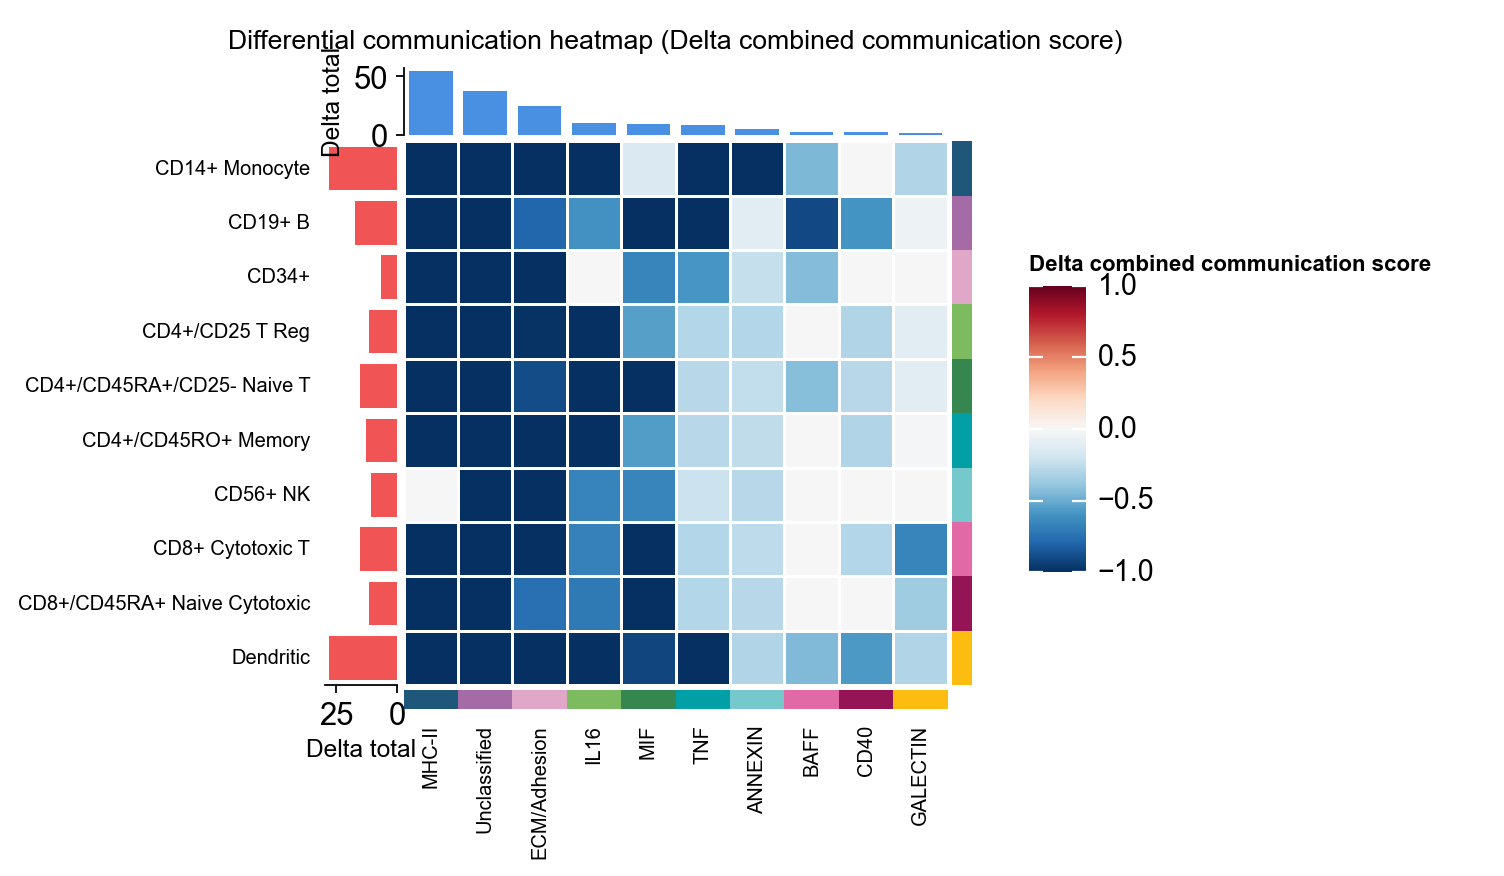

In [19]:
fig, ax = ov.pl.ccc_heatmap(
    adata,
    comparison_adata=comparison_comm,
    plot_type='diff_heatmap',
    top_n=10,
    figsize=(5,5),
    show=False,
    show_col_names=True,
    show_row_names=True,
)

# 2. `ov.pl.ccc_network_plot`

Heatmaps are good for matrix structure. Network plots are better for questions such as:

- which cell groups act as dominant senders or receivers
- what the overall direction of one pathway looks like
- where a specific ligand or receptor sits in the communication graph


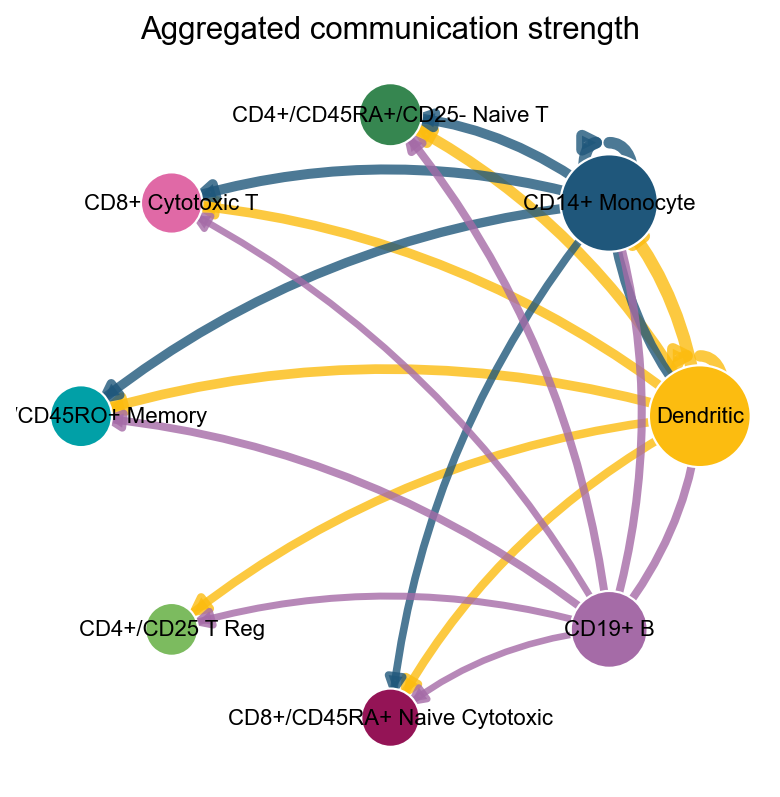

In [20]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='circle',
    palette=color_dict,
    title='Aggregated communication strength',
    figsize=(6, 6),
    show=False,
)

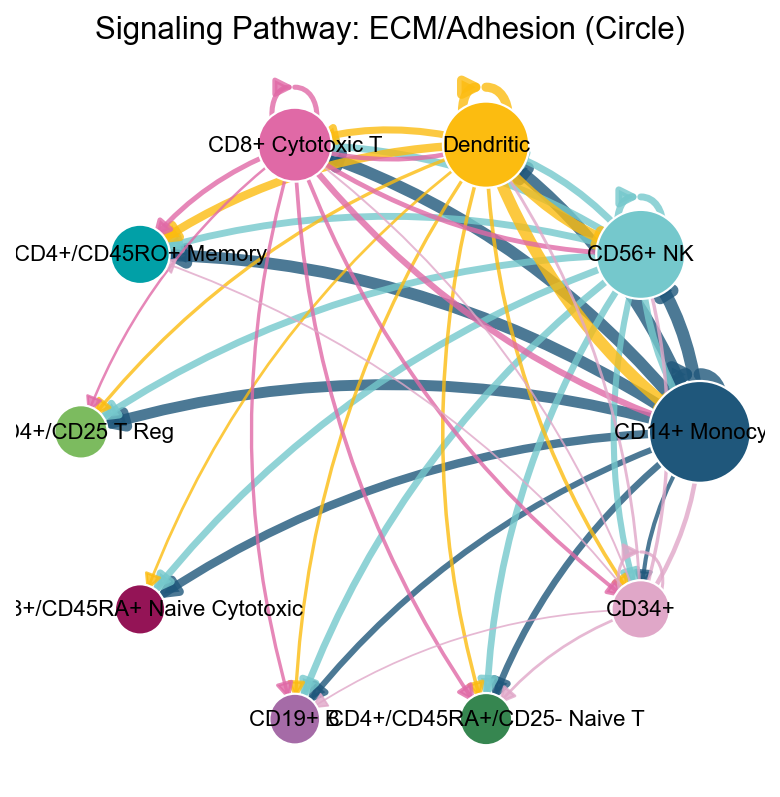

In [21]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='pathway',
    signaling=['ECM/Adhesion'],
    palette=color_dict,
    top_n=50,
    figsize=(6, 6),
    show=False,
)

`embedding_network` overlays the communication network on a low-dimensional embedding. Background points show the distribution of cells in transcriptomic space, larger nodes represent aggregated cell-type nodes, and edges show the direction and strength of communication. This is useful when you want to inspect whether stronger communication tends to occur between nearby or functionally related cell groups in embedding space.


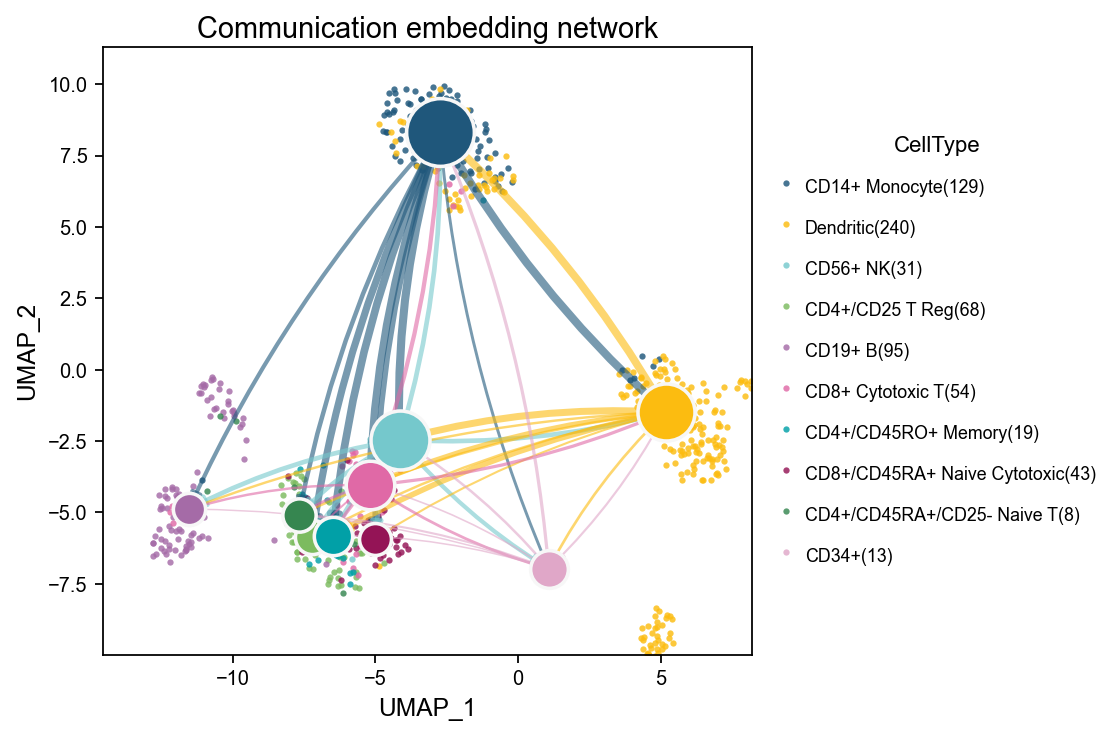

In [22]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='embedding_network',
    signaling=['ECM/Adhesion'],
    node_positions=node_positions,
    embedding_points=embedding_points,
    palette=color_dict,
    top_n=50,
    figsize=(6, 5),
    show=False,
)

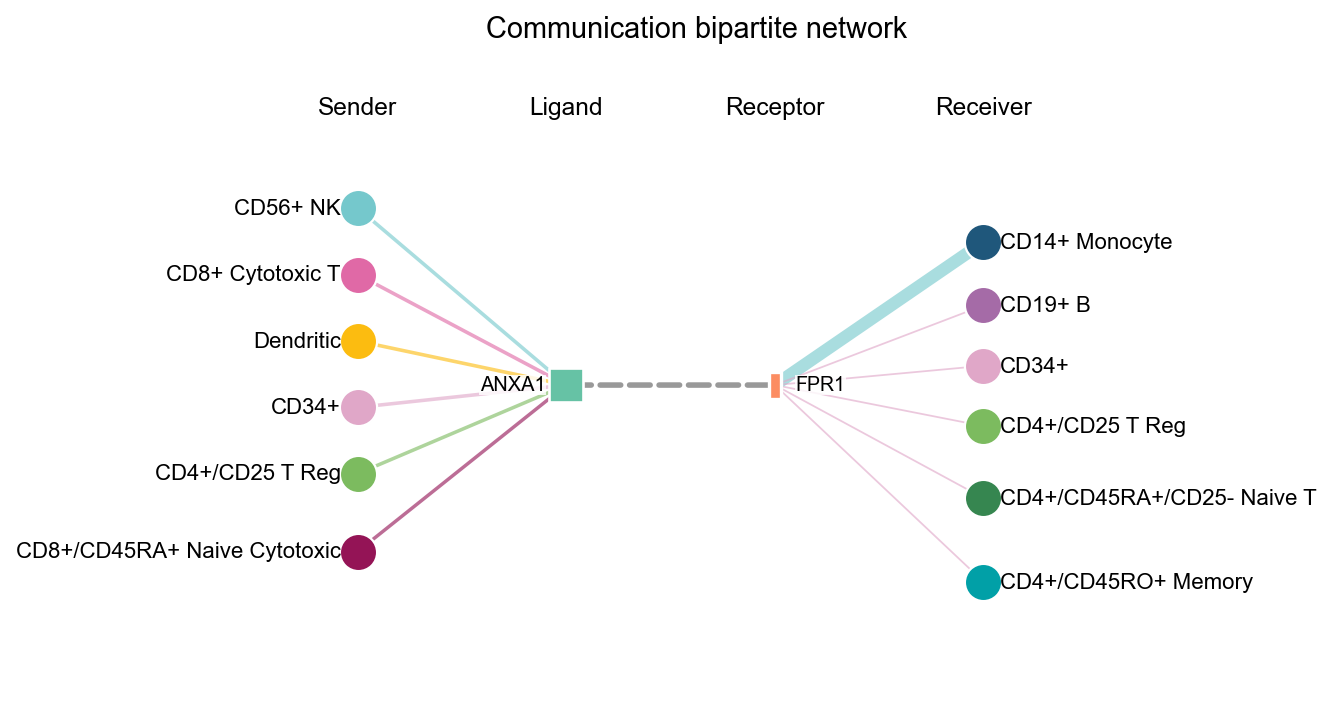

In [23]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='bipartite',
    ligand=focus_ligand,
    palette=color_dict,
    top_n=6,
    figsize=(6, 5),
    show=False,
)

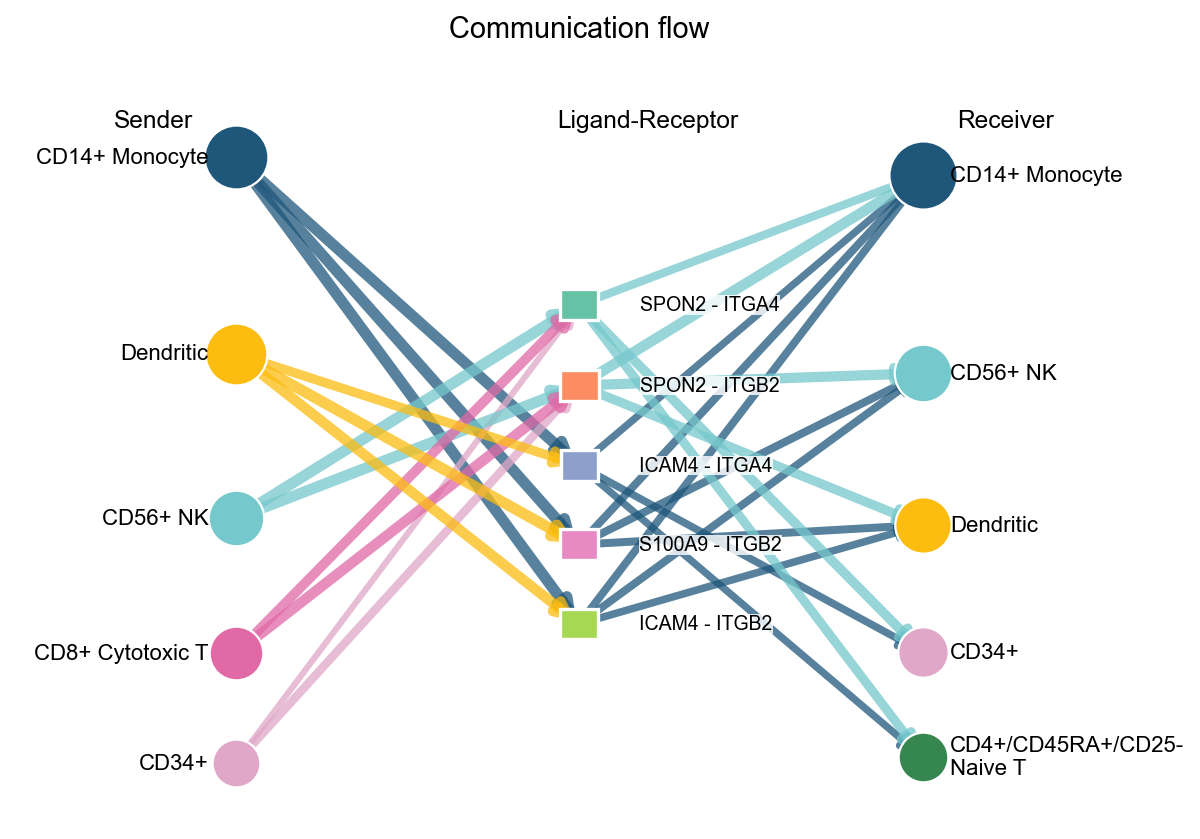

In [24]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='arrow',
    display_by='interaction',
    signaling=['ECM/Adhesion'],
    palette=color_dict,
    top_n=5,
    figsize=(8, 6),
    show=False,
)

`arrow` and `sigmoid` also support `display_by='aggregation'`. In that mode, the plot only keeps sender-receiver pathway relations, and `top_n` controls how many relations are shown.


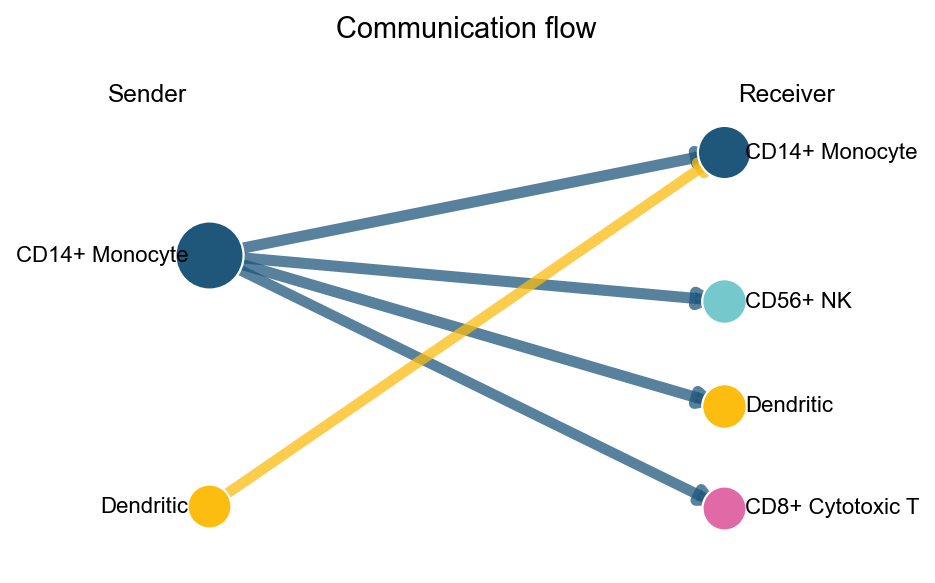

In [25]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='arrow',
    display_by='aggregation',
    signaling=['ECM/Adhesion'],
    palette=color_dict,
    top_n=5,
    figsize=(6, 4),
    show=False,
)

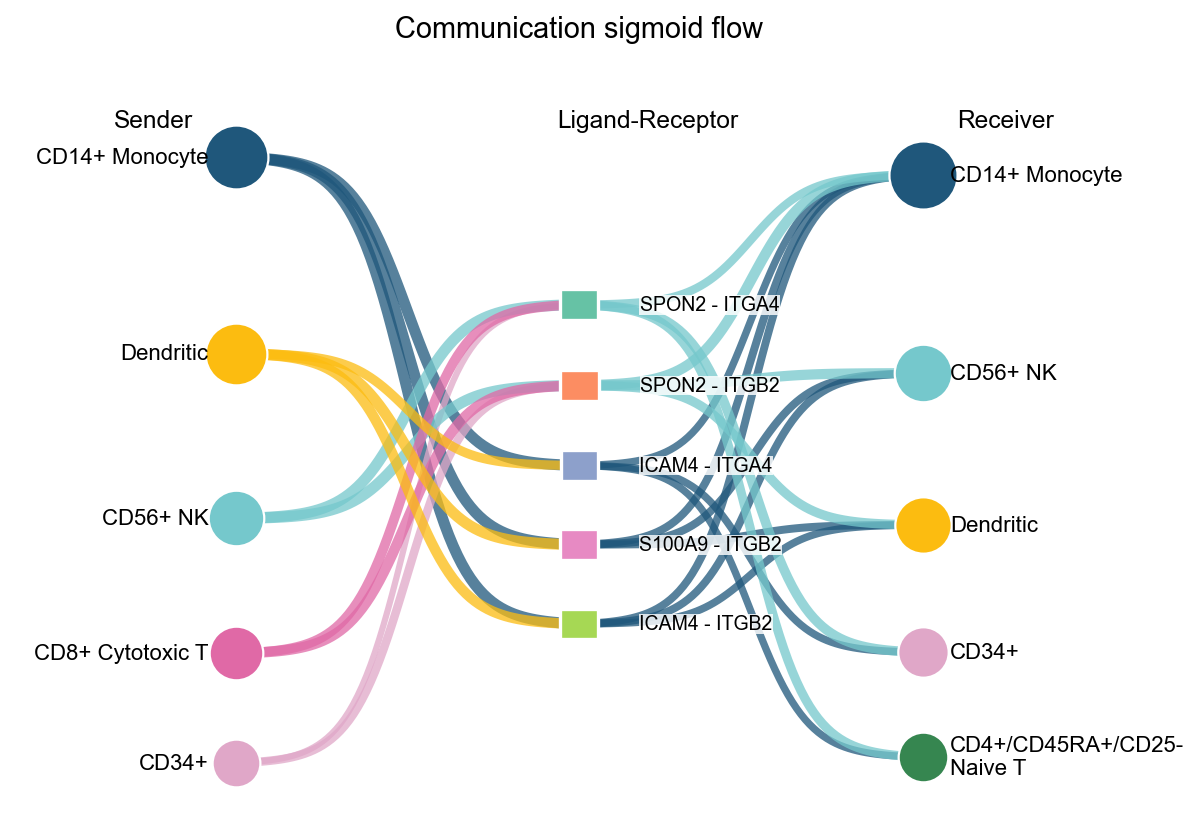

In [26]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='sigmoid',
    display_by='interaction',
    signaling=['ECM/Adhesion'],
    palette=color_dict,
    top_n=5,
    figsize=(8, 6),
    show=False,
)

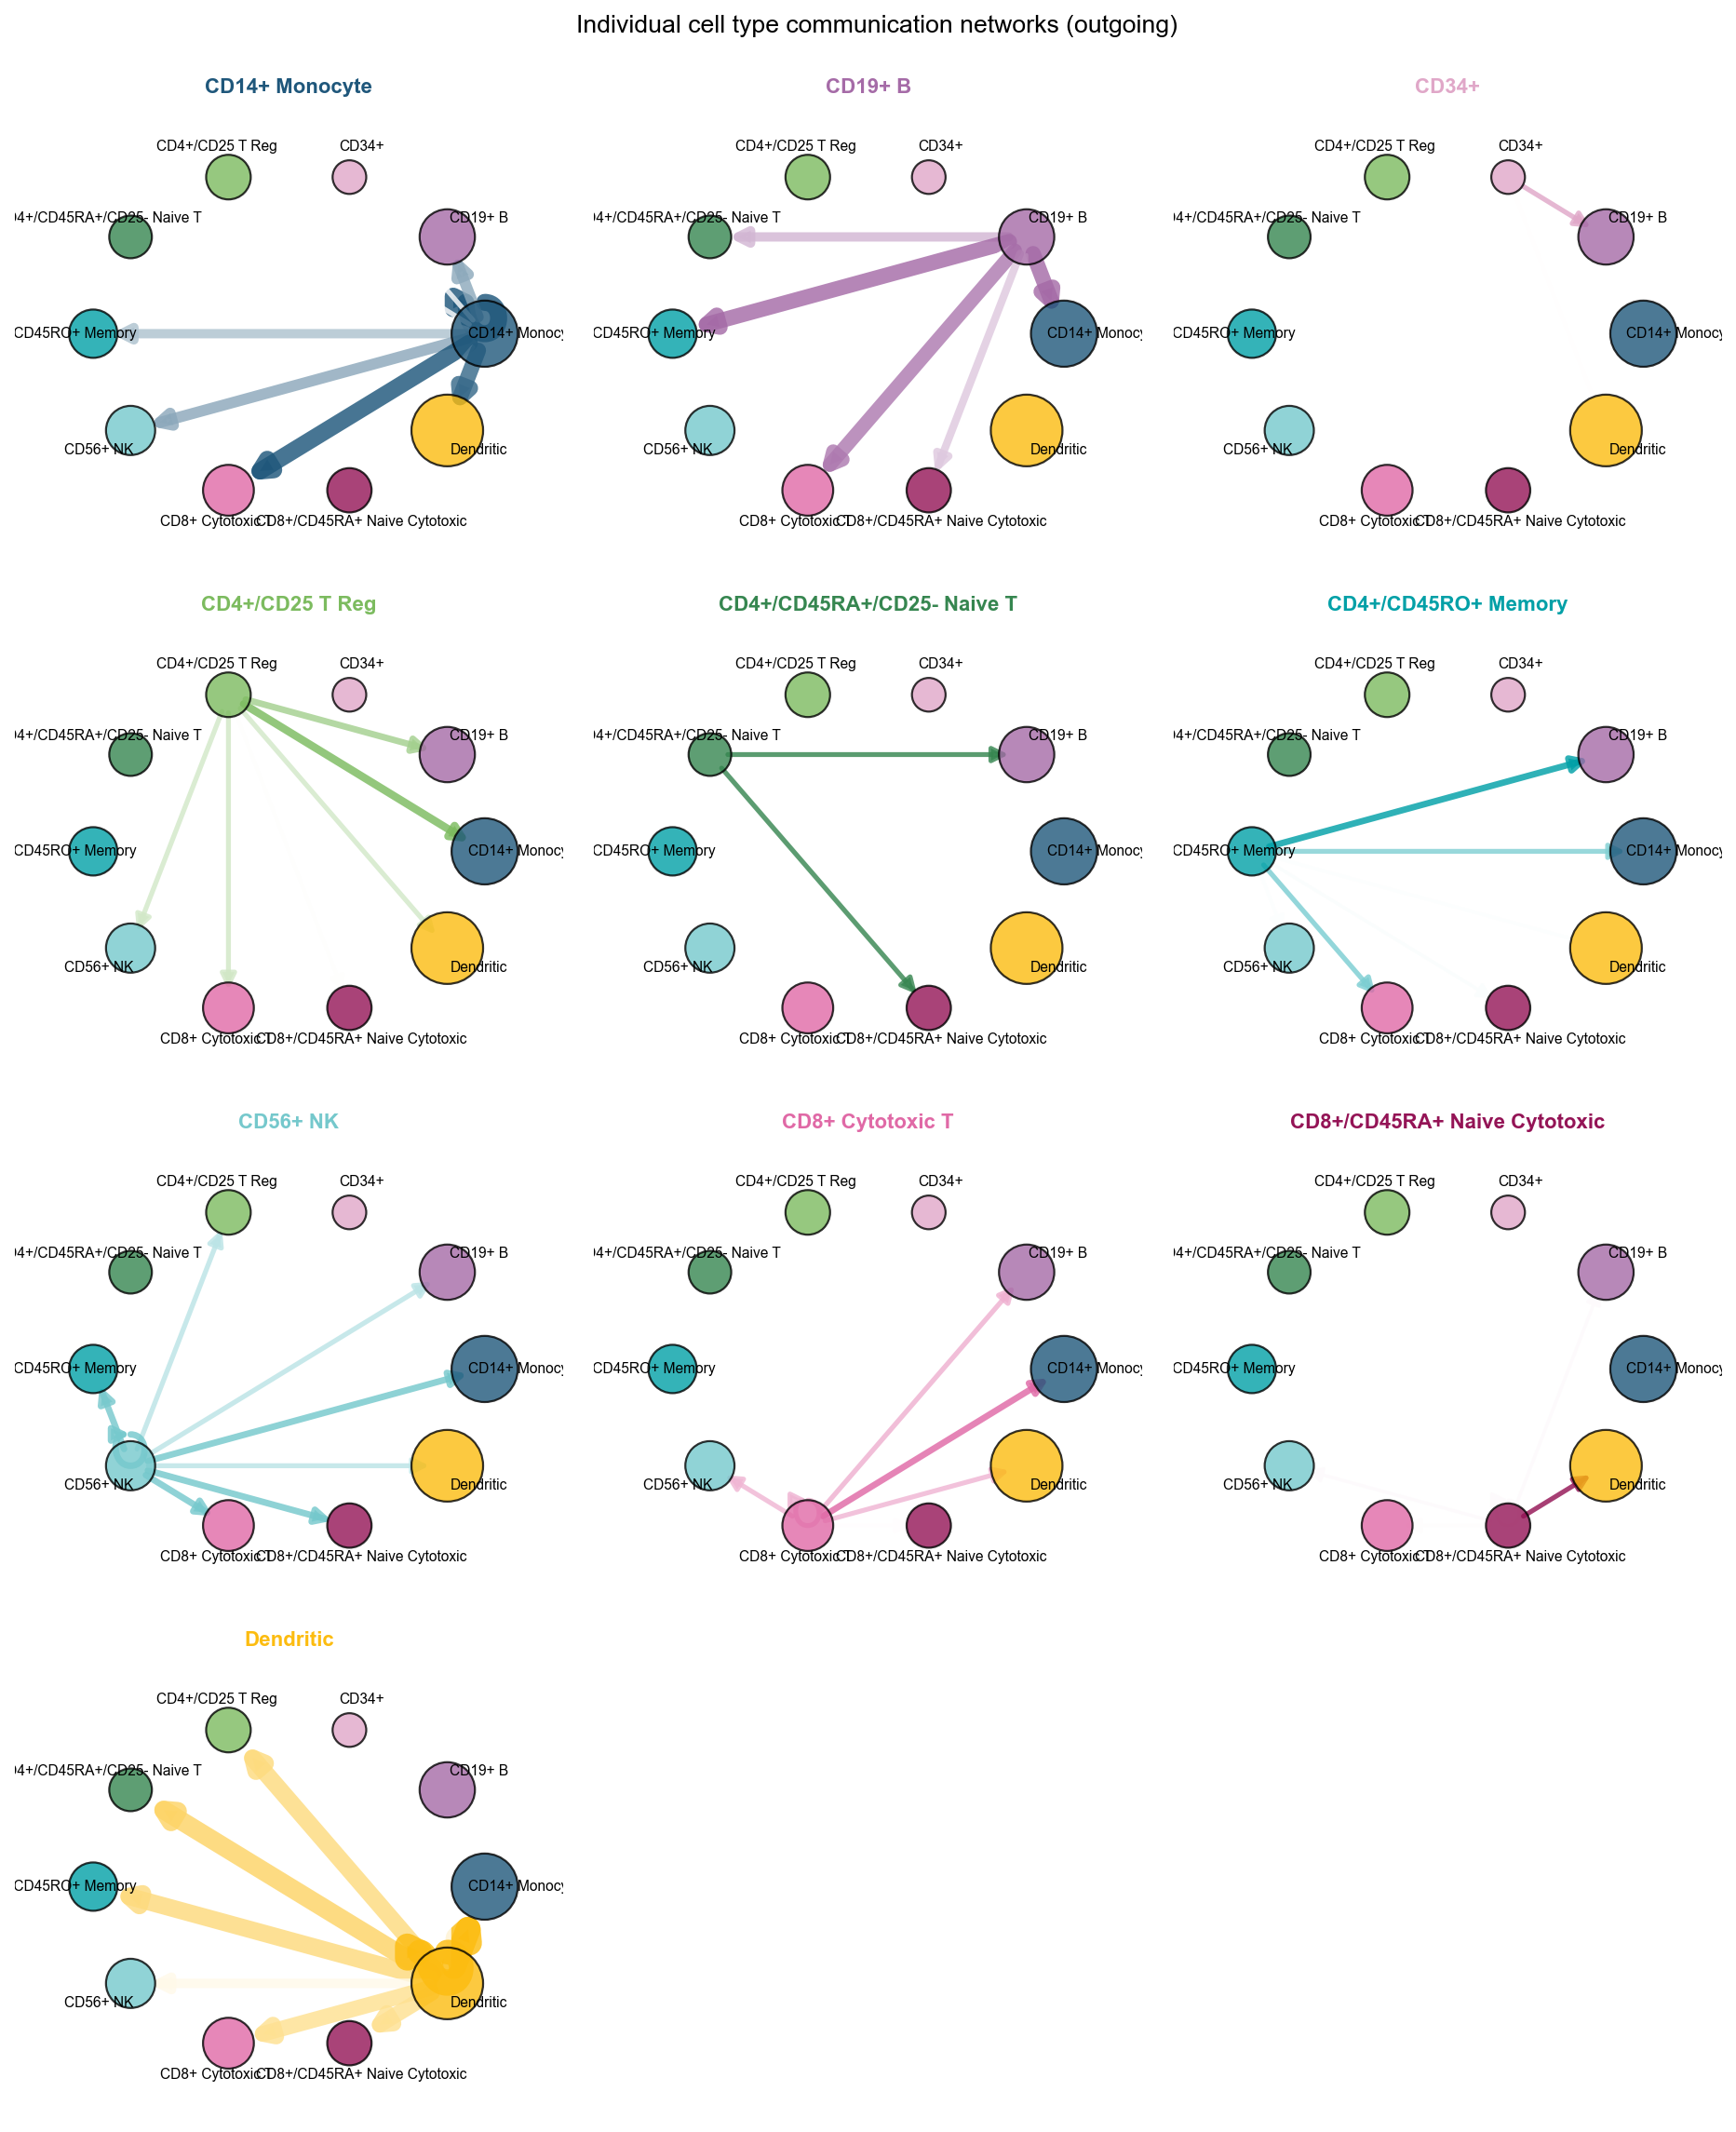

In [27]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='individual_outgoing',
    figsize=(12, 15),
    ncols=3,
    show=False,
)

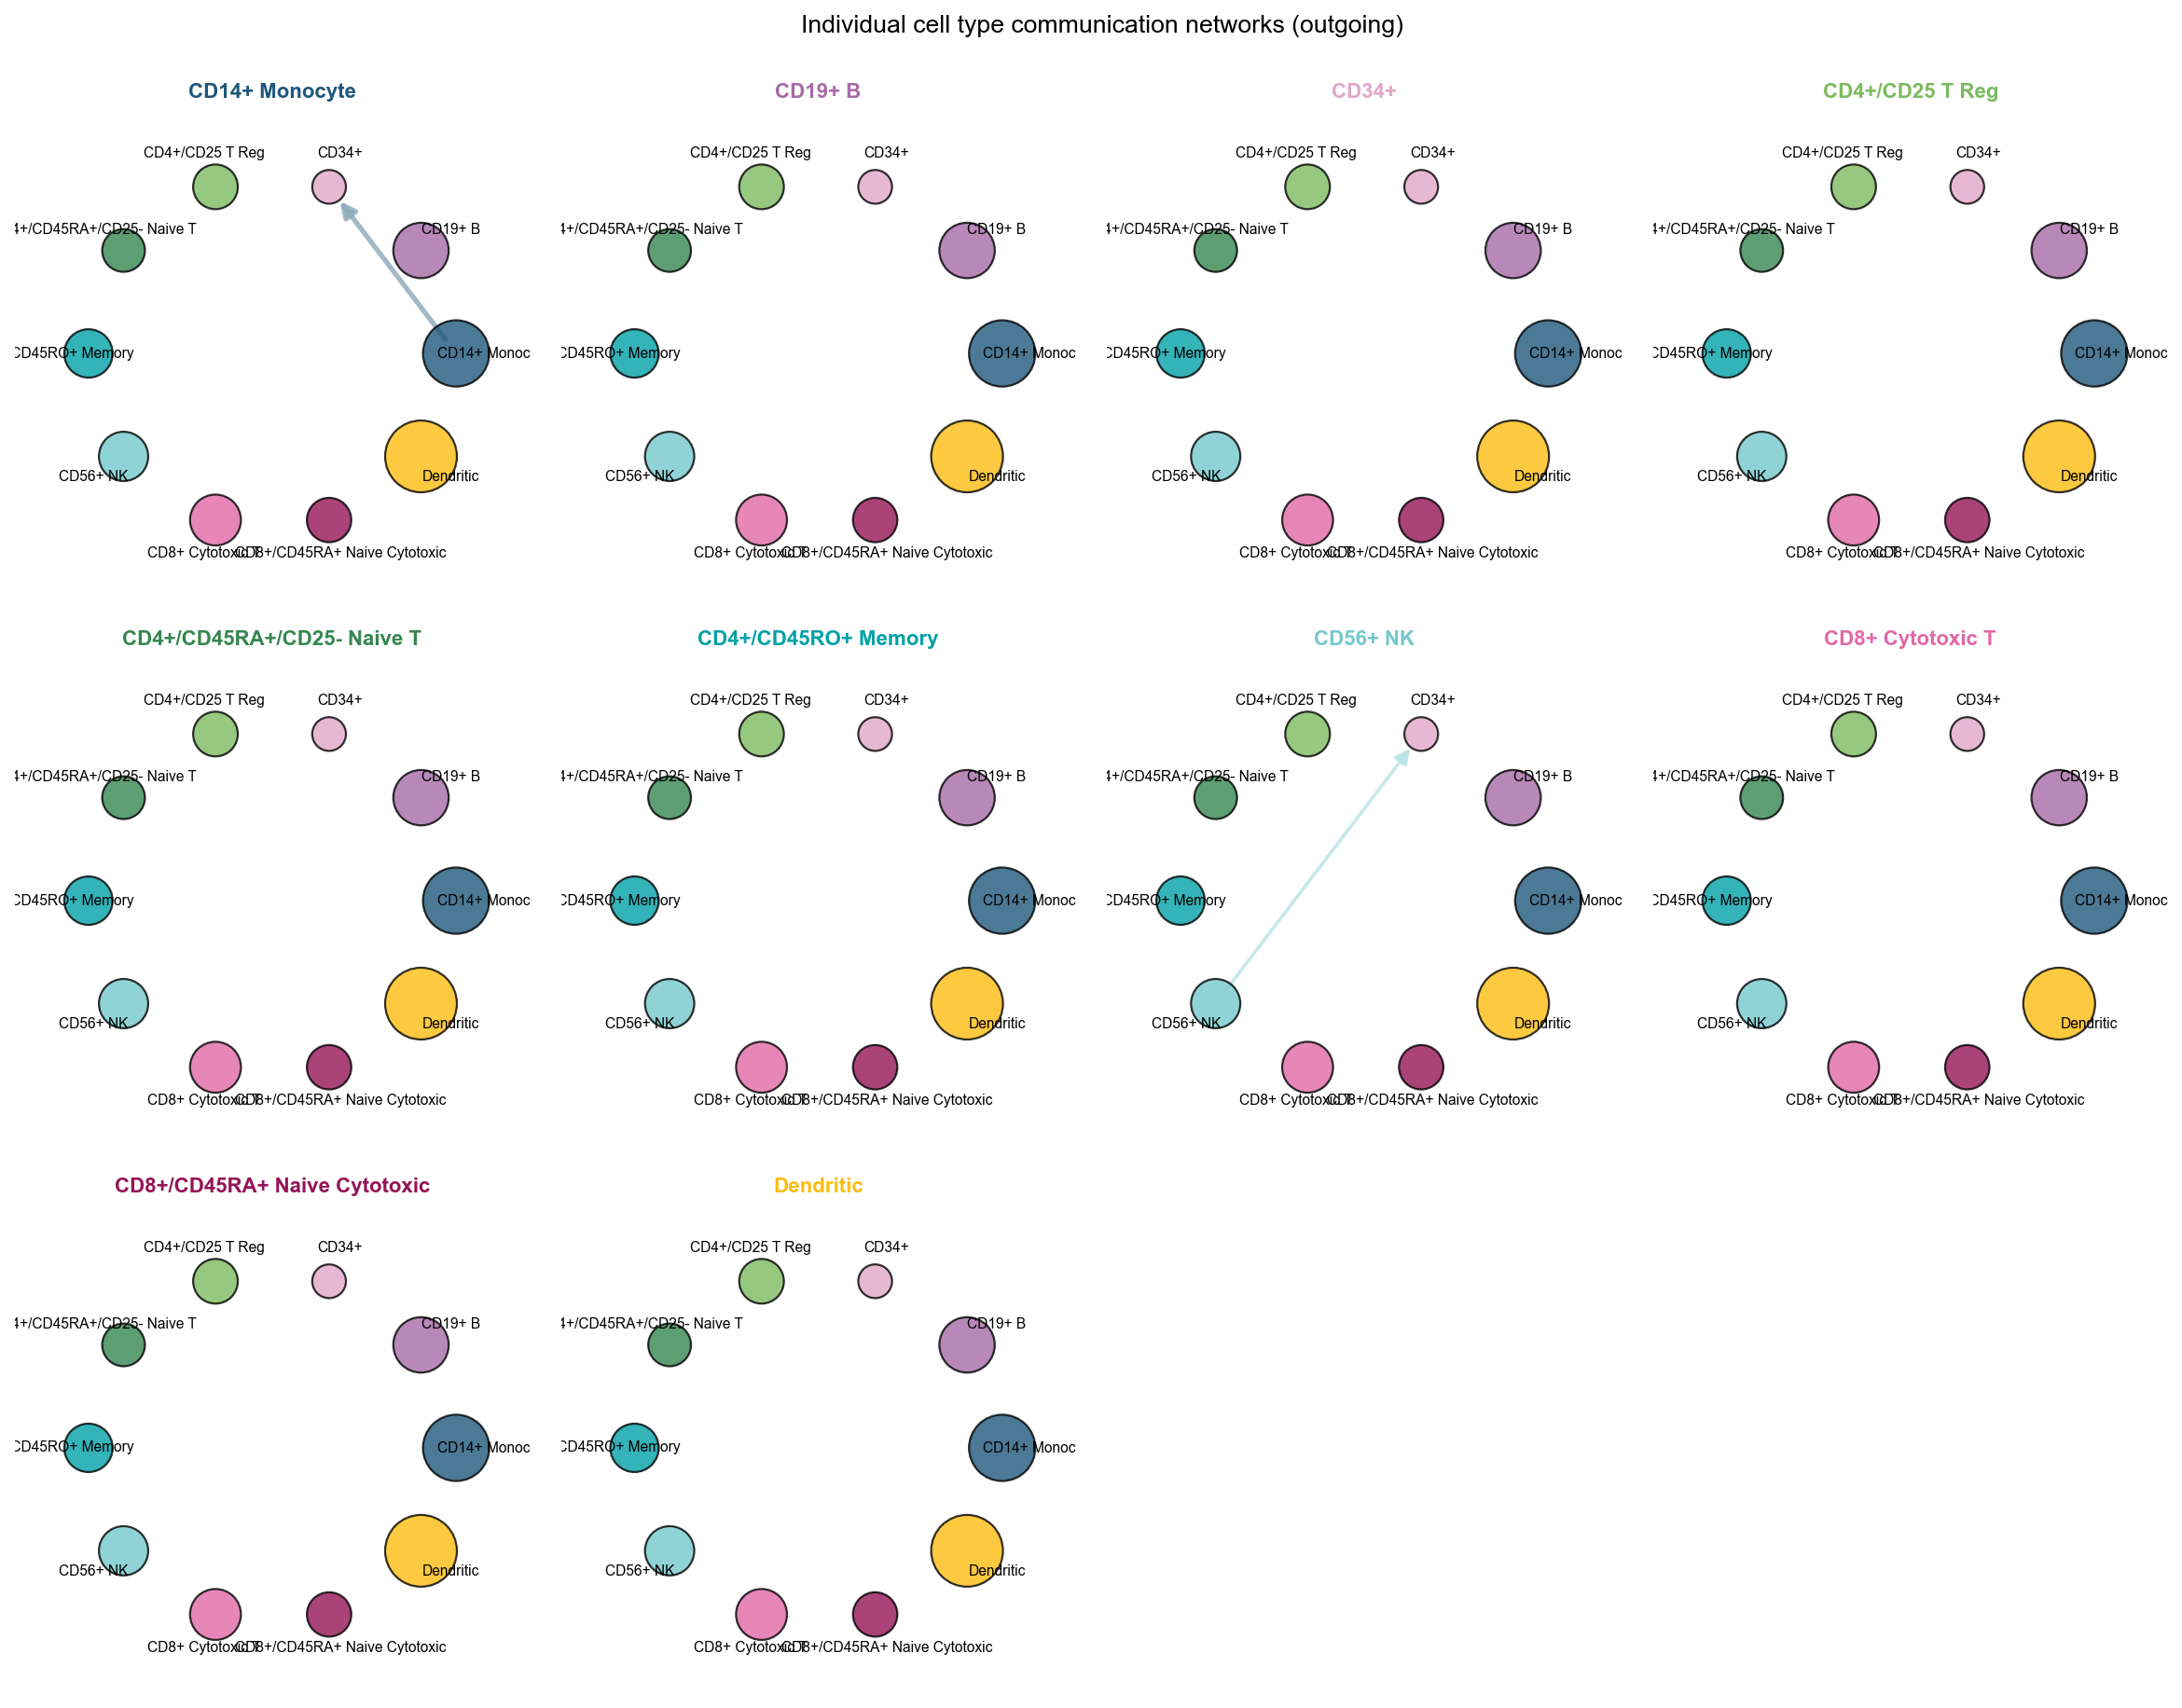

In [28]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='individual_outgoing',
    receiver_use='CD34+',
    figsize=(15, 12),
    show=False,
)

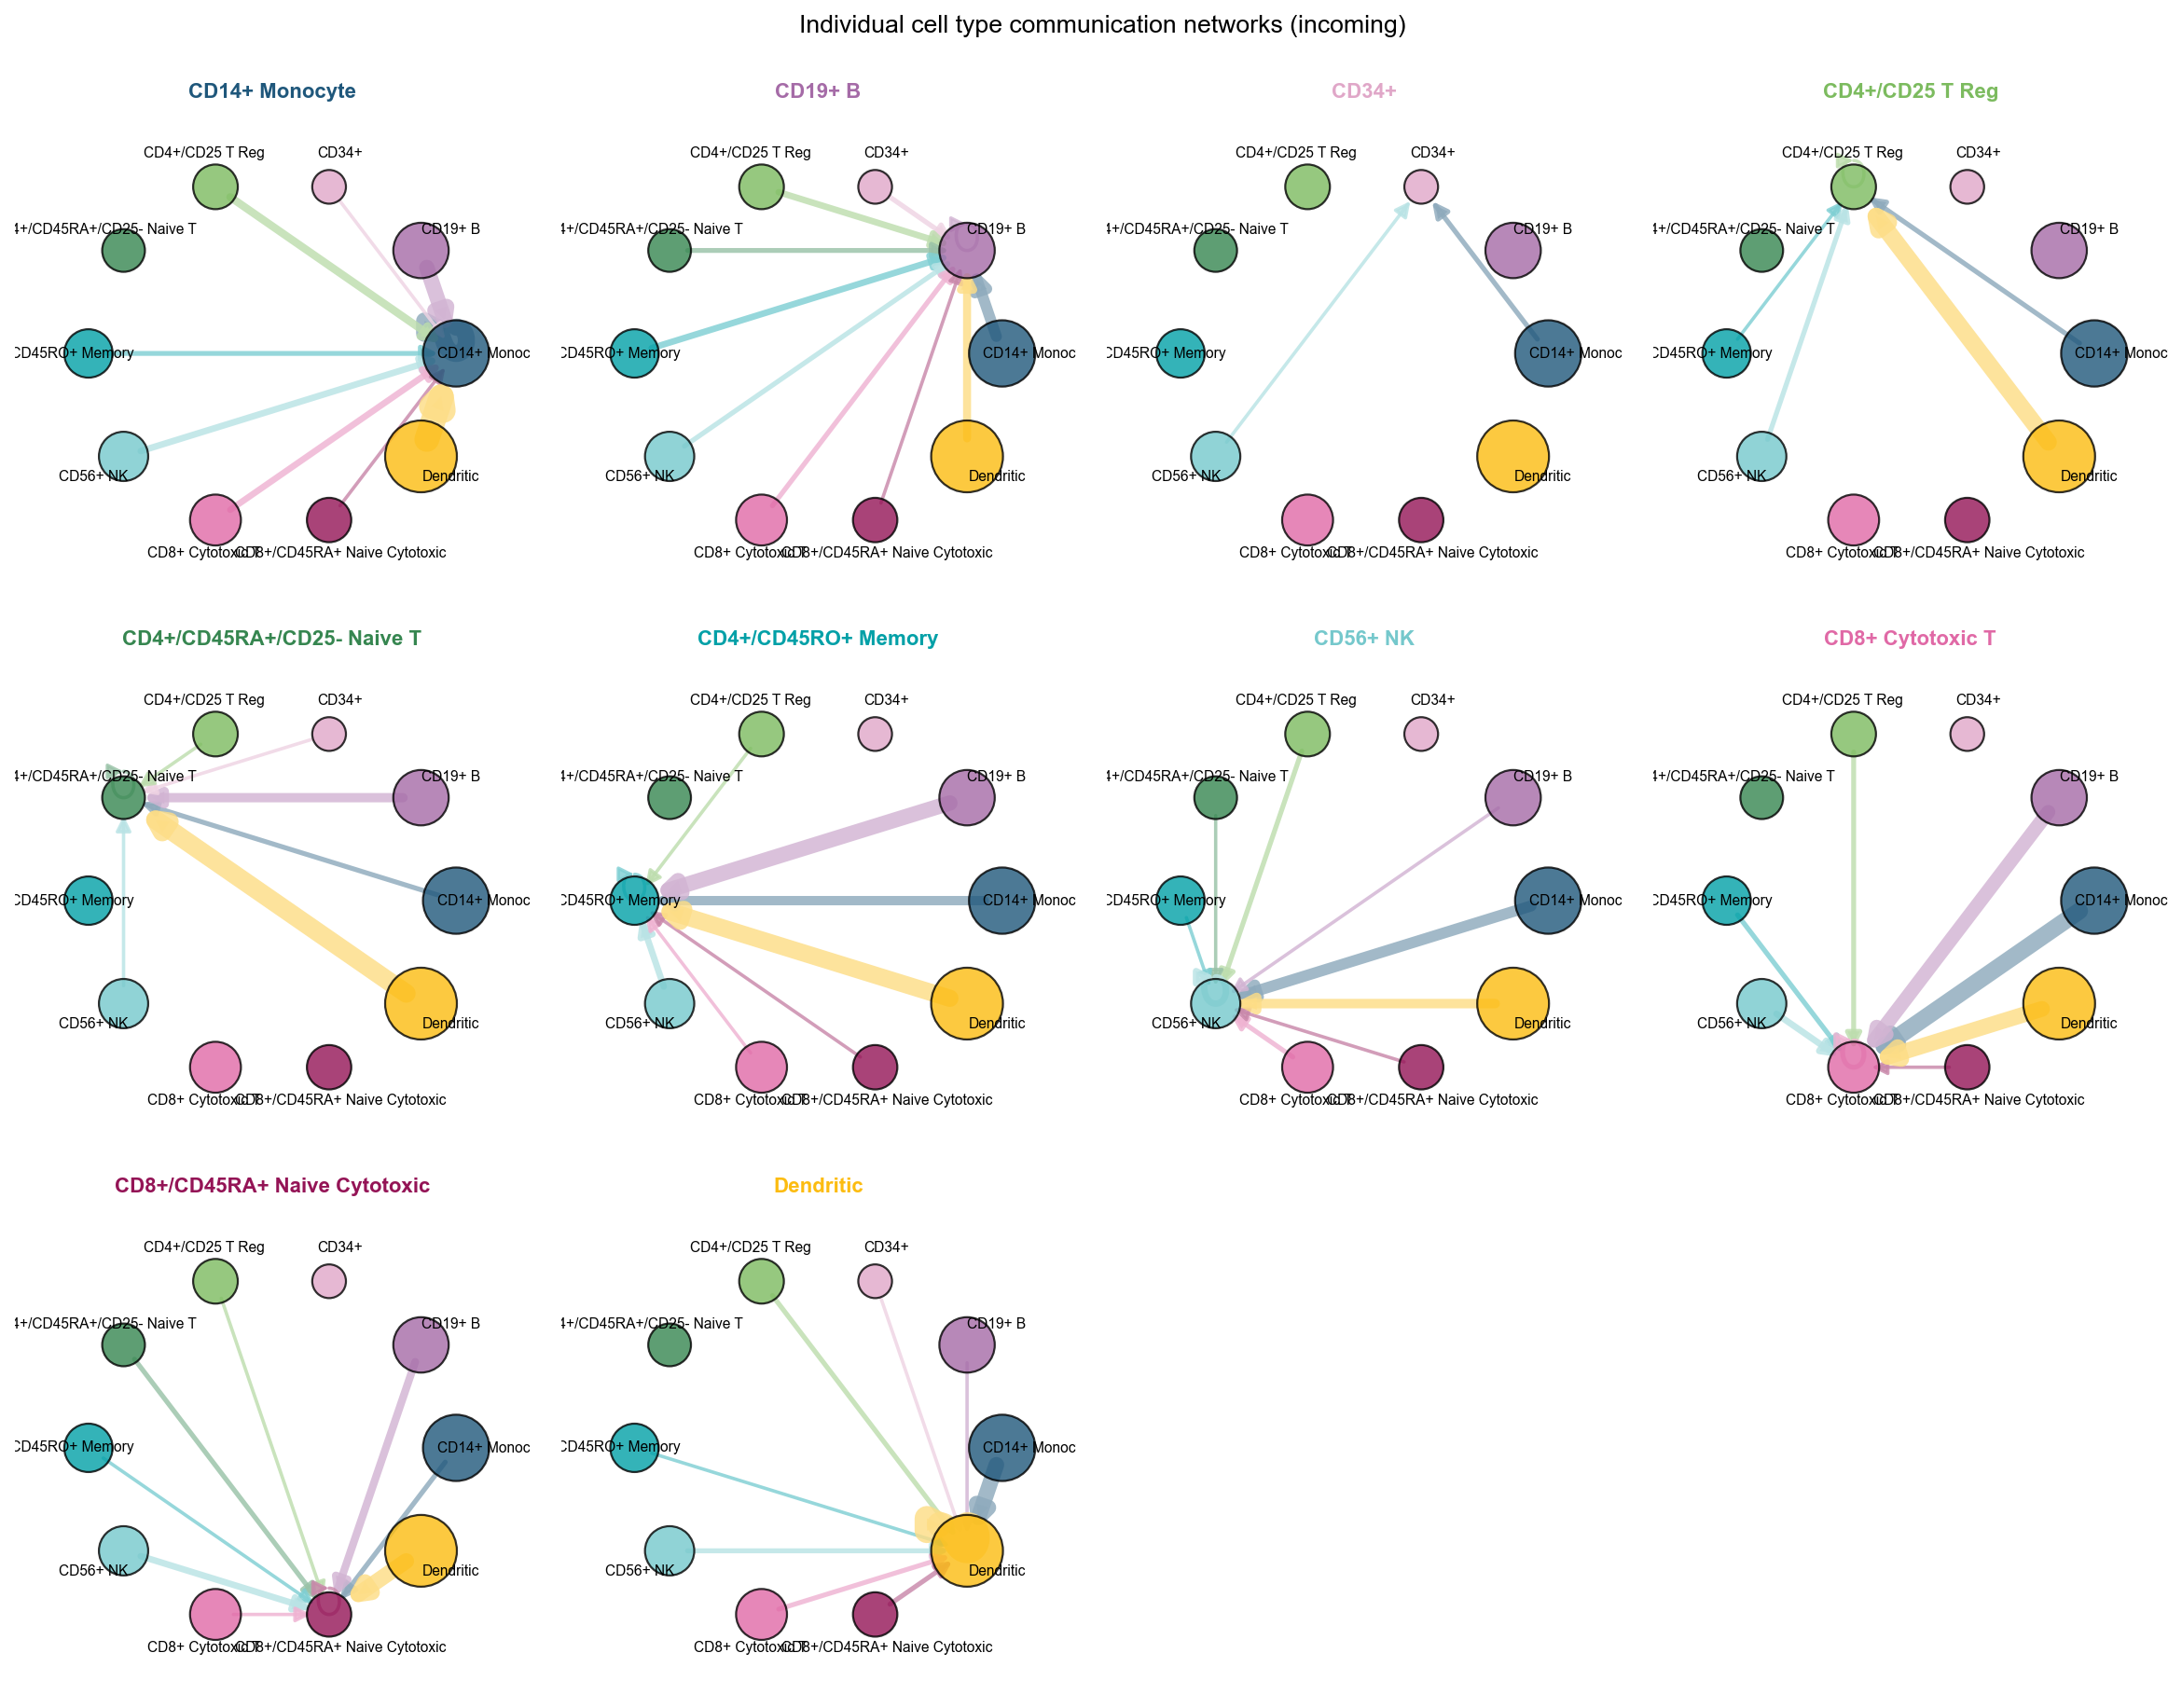

In [29]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='individual_incoming',
    figsize=(15, 12),
    show=False,
)

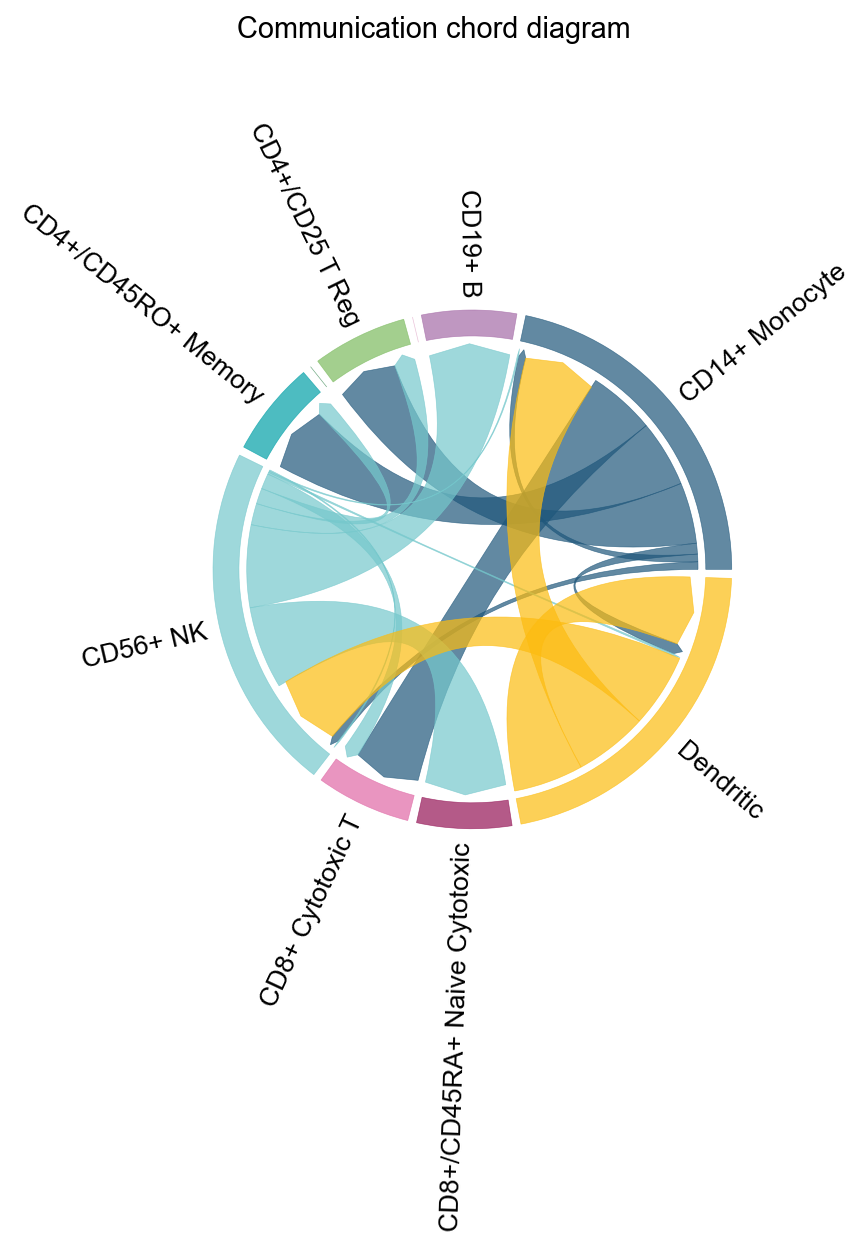

In [30]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='chord',
    signaling=['ECM/Adhesion'],
    normalize_to_sender=True,
    figsize=(8, 8),
    show=False,
)

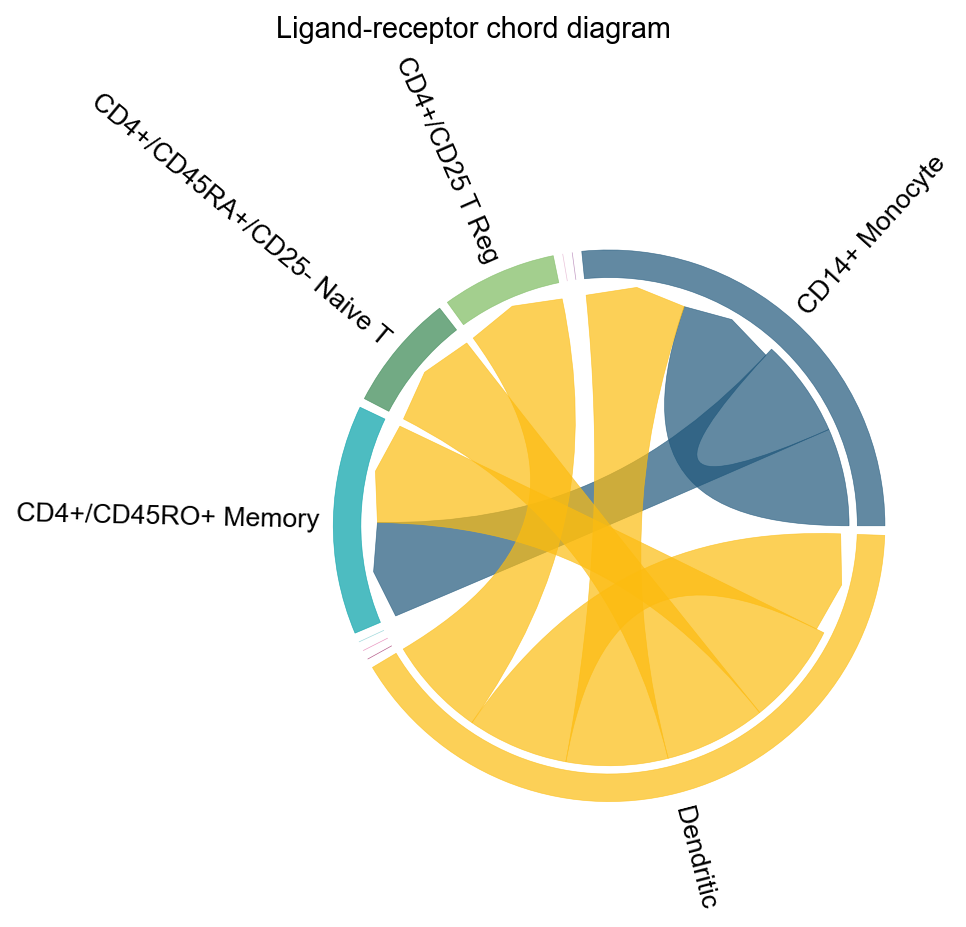

In [31]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    plot_type='lr_chord',
    pair_lr_use=focus_pair_lr,
    palette=color_dict,
    figsize=(6, 6),
    show=False,
)

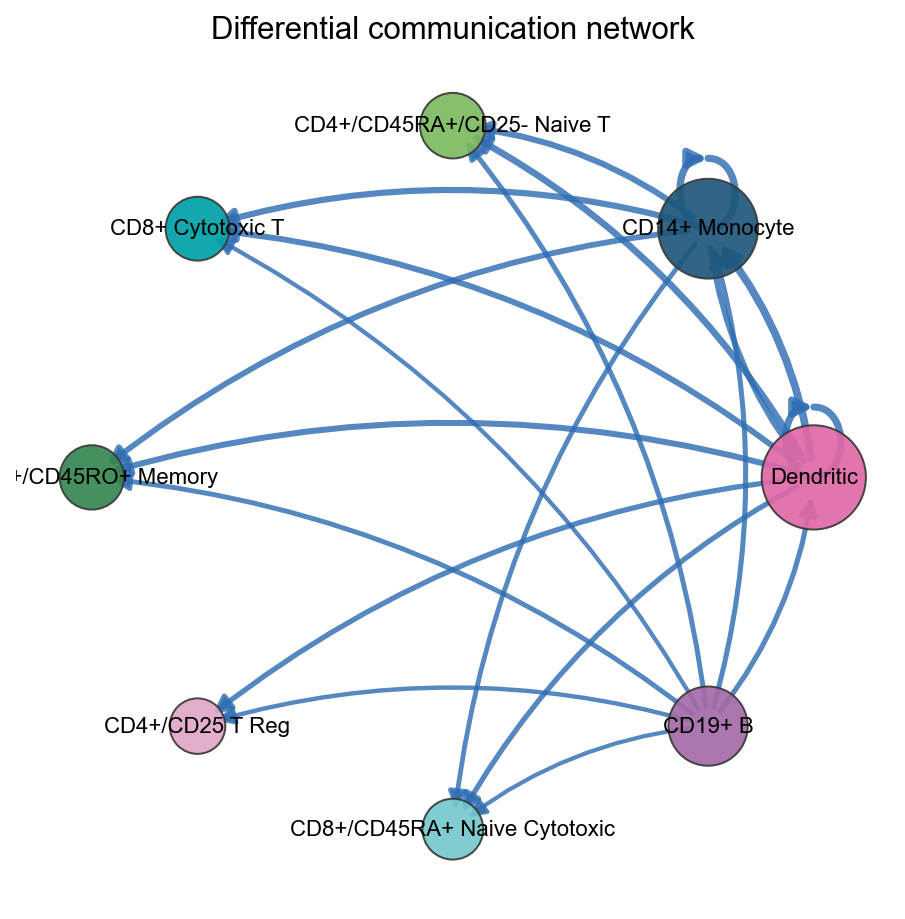

In [32]:
fig, ax = ov.pl.ccc_network_plot(
    adata,
    comparison_adata=comparison_comm,
    plot_type='diff_network',
    top_n=20,
    show=False,
)

# 3. `ov.pl.ccc_stat_plot`

Statistical summary plots are used for ranking, compression, and explanation:

- `bar`: the most compact interaction/pathway ranking
- `scatter`: overview of communication distributions
- `sankey`: sender/receiver/interaction flow structure
- `pathway_summary`: pathway-level total strength plus significant pair counts
- `lr_contribution`: which ligand-receptor pairs explain one pathway


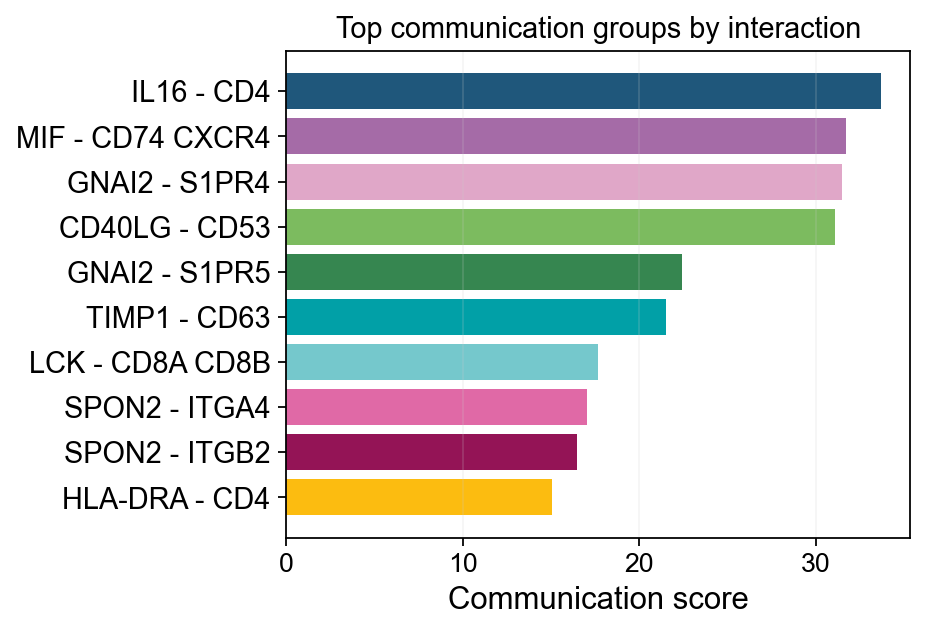

In [33]:
fig, ax = ov.pl.ccc_stat_plot(
    adata,
    plot_type='bar',
    display_by='interaction',
    score_key='specificity_rank',
    pvalue_key='specificity_rank',
    group_by='interaction',
    top_n=10,
    figsize=(5, 4),
    show=False,
)

✅ Network centrality calculation completed (CellChat-style Importance values)
   - Signaling pathways used: All pathways
   - Weight mode: Weighted
   - Calculated metrics: outdegree, indegree, flow_betweenness, information, overall
   - All centrality scores normalized to 0-1 range (Importance values)


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


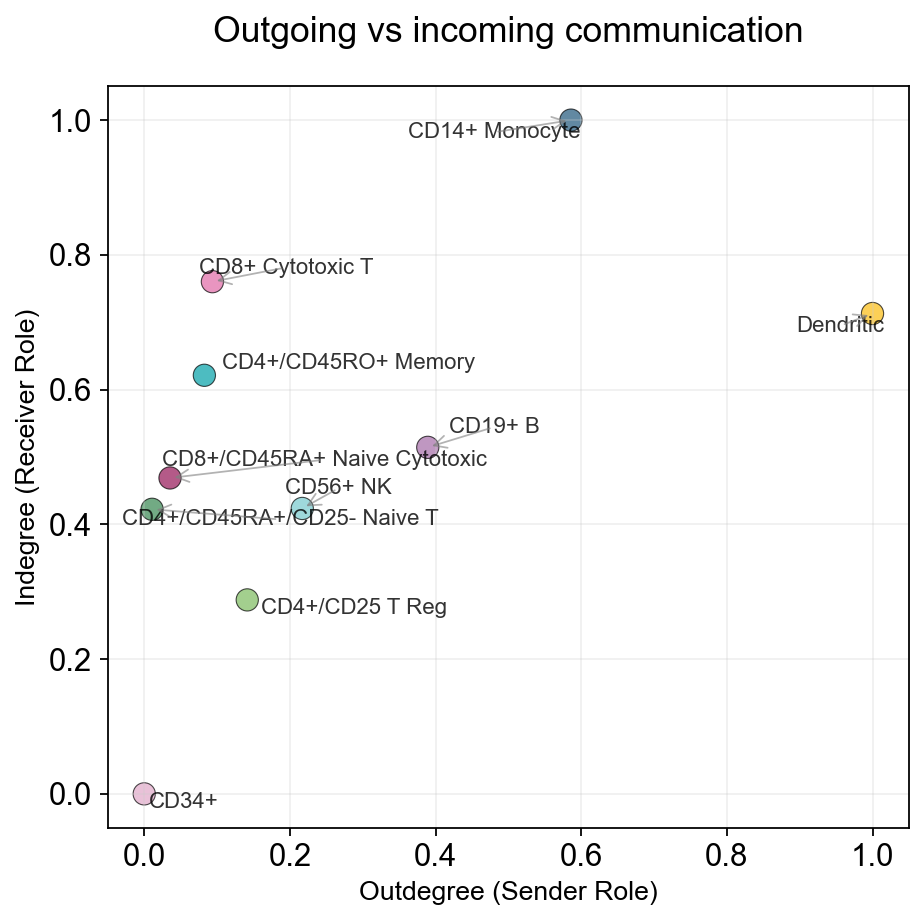

In [34]:
fig, ax = ov.pl.ccc_stat_plot(
    adata,
    plot_type='scatter',
    figsize=(6, 6),
    show=False,
)

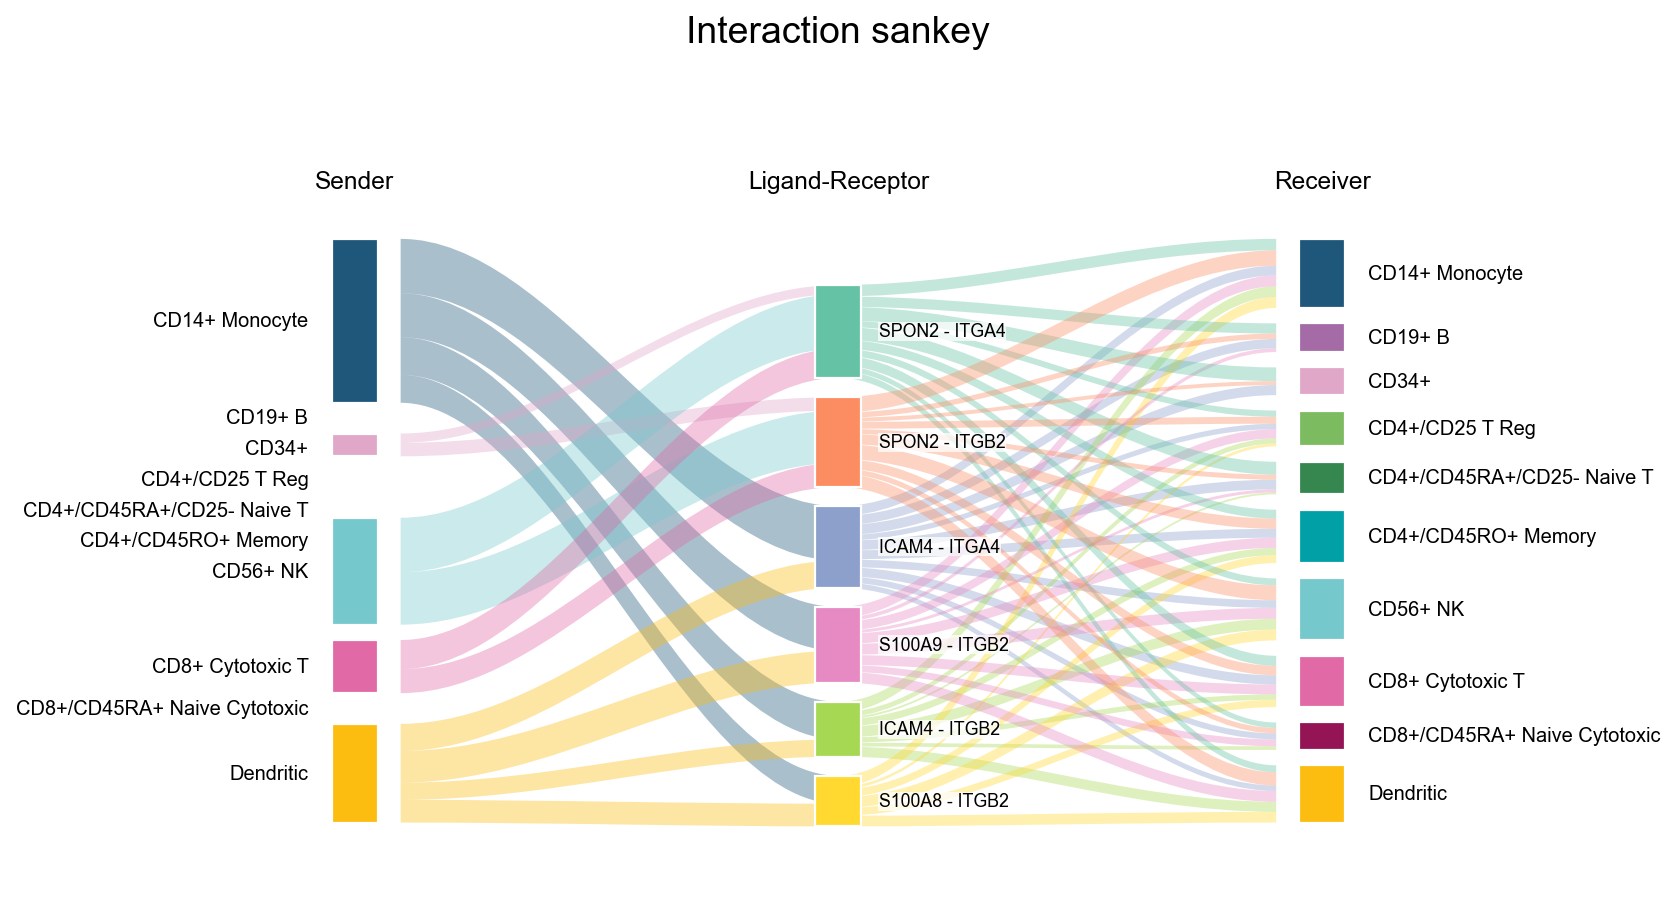

In [35]:
fig, ax = ov.pl.ccc_stat_plot(
    adata,
    plot_type='sankey',
    display_by='interaction',
    signaling=['ECM/Adhesion'],
    figsize=(8, 6),
    show=False,
)

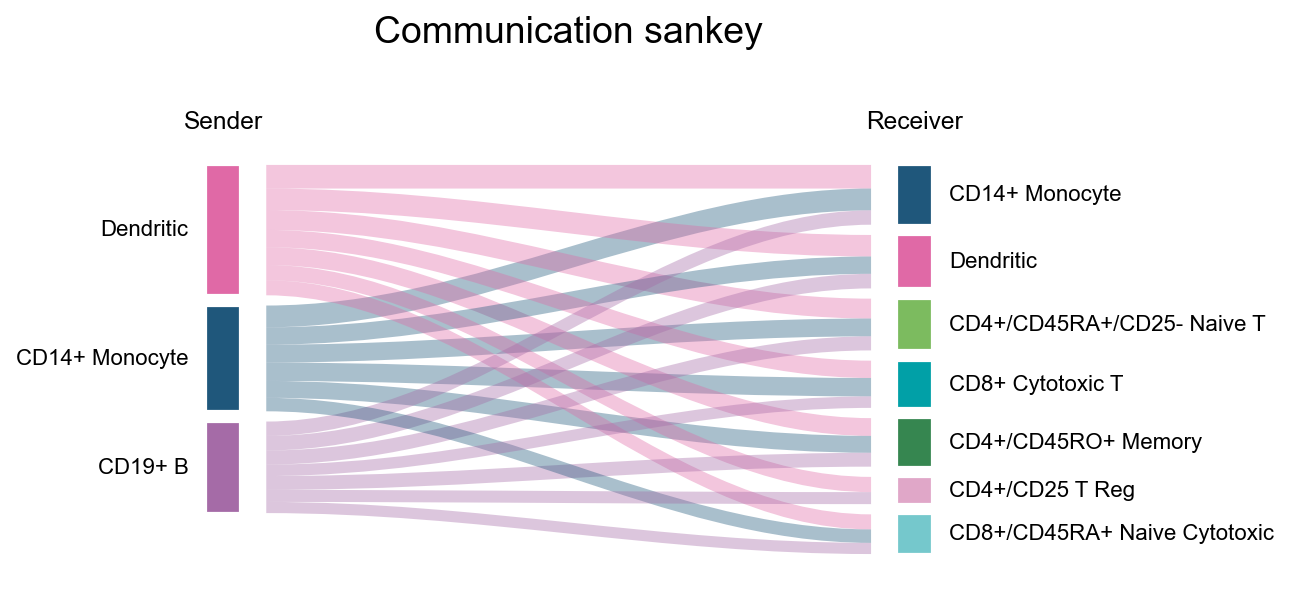

In [36]:
fig, ax = ov.pl.ccc_stat_plot(
    adata,
    plot_type='sankey',
    display_by='aggregation',
    figsize=(6, 4),
    show=False,
)

🔬 Calculating cell communication strength for 11 pathways...
   - Aggregation method: mean
   - Minimum expression threshold: 0.0
✅ Completed pathway communication strength calculation for 11 pathways
📊 Pathway significance analysis results:
   - Total pathways: 11
   - Significant pathways: 11
   - Strength threshold: 0.0
   - p-value threshold: 0.05

🏆 Top 10 pathways by total strength:
----------------------------------------------------------------------------------------------------
Pathway                        Total    Max     Mean    L-R  Active Sig  Rate   Status
----------------------------------------------------------------------------------------------------
IL16                           33.69    0.98    0.84    1    40     10   0.25   ***
MIF                            31.72    0.98    0.62    1    51     5    0.10   ***
Unclassified                   24.84    0.67    0.30    5    82     33   0.40   ***
ECM/Adhesion                   13.60    0.67    0.29    6    47    

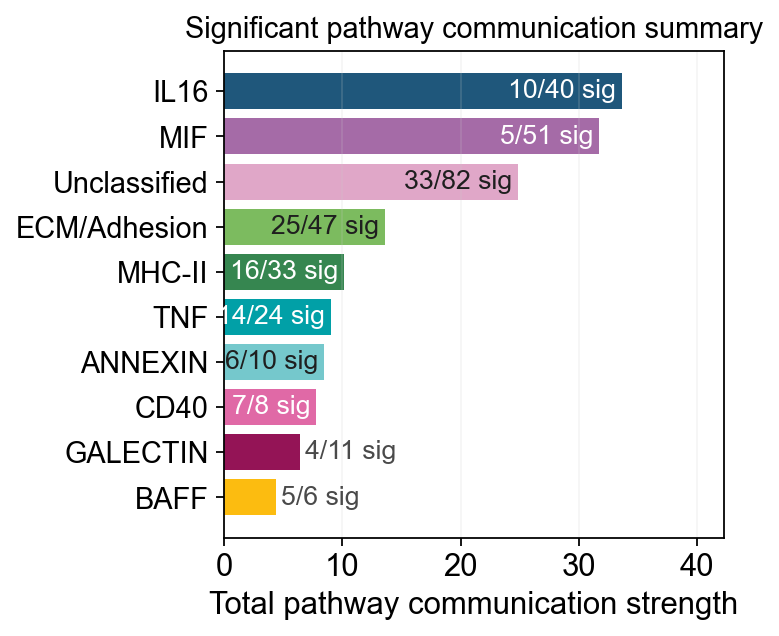

In [37]:
fig, ax = ov.pl.ccc_stat_plot(
    adata,
    plot_type='pathway_summary',
    score_key='specificity_rank',
    pvalue_key='specificity_rank',
    classification_reference='cellchat',
    classification_fallback='family',
    top_n=10,
    pvalue_threshold=0.05,
    min_expression=0.0,
    strength_threshold=0.0,
    min_significant_pairs=1,
    figsize=(4, 4),
    verbose=True,
    show=False,
)

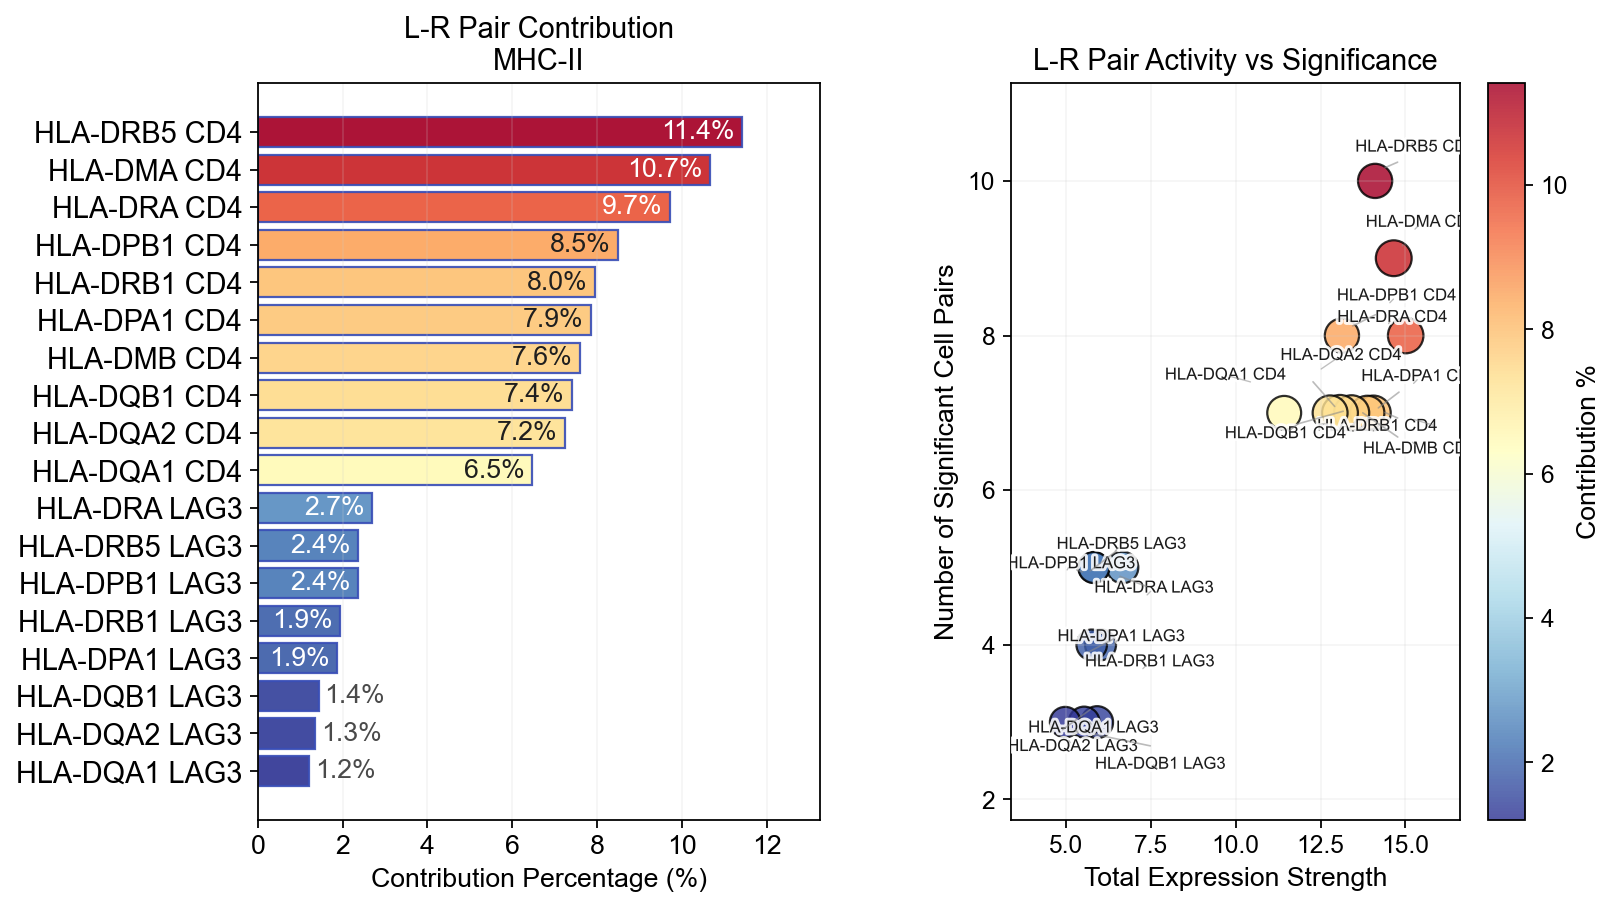

In [38]:
fig, ax = ov.pl.ccc_stat_plot(
    adata,
    plot_type='lr_contribution',
    signaling=['MHC-II'],
    figsize=(10, 6),
    show=False,
)